# 31 — Dead-zone training target: fitting to the credible-interval-clipped prediction

**Screen, then conditionally submit.** Every prior calibration in this project (notebooks 16,
26, 27) is an affine transform of a whole prediction column — it cannot change Spearman, only
placement/spread. This notebook tests something structurally different: replacing the training
TARGET itself with `clip(oof_prediction, conf_low, conf_high)` under absolute-error loss, so a
model that already predicts within a compound's own published credible band gets zero gradient
there and full gradient only for compounds it is actually getting outside their band. Because
each compound's band has a different width, this moves compounds by different amounts — it can
reorder them, which no affine correction in this project ever could.

**Honest prior, stated before any training.** Eight modelling screens on this project (18, 20,
22, 24, 25, 26, 28-confirmed-then-disconfirmed-at-25-fold-CV-in-29, and 29's own result failing
to transfer to the board as NB30) have produced one confirmed CV effect, and that effect then
lost on the real board. A null result here is a legitimate and likely outcome, not a failure of
this notebook.

**External prior, labelled external throughout, never mixed with this project's own numbers**: an
independent entrant on this exact challenge reports +0.0197 mean rank gain and −0.0199 mean
ST-RAE gain from this exact target, against a four-seed macro floor of 0.0036, sign holding in
16/16 per-enzyme cells. Per-isoform: CYP2D6 +0.0523, CYP2C9 +0.0407, CYP1A2 +0.0402, CYP3A4
+0.0025 (inside its own floor, explained by 73.9% of their CYP3A4 wide-band predictions already
sitting inside the band).

**Scope**: three-arm, one-fold, three-seed screen (Part 2), scored per the frozen pre-registration
(Part 1) after a headroom check (Part 0). A full-data retrain and submission candidate is built
**only if** the frozen bar in Part 1 is met — see Part 4, which is either executed or replaced by
a one-line stop, never softened. No submission is sent from this notebook under any outcome.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import importlib.metadata
import inspect
import json
import time
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

from src.vendor.openadmet_eval.config import REGRESSION_ENDPOINTS
from src.vendor.openadmet_eval.custom_scoring_functions import rae_soft_threshold_absolute_error

print(f"python: {sys.version.split()[0]}")
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "chemprop", "torch"]:
    try:
        print(f"{pkg}: {importlib.metadata.version(pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

ISOFORMS = [e.split("_")[0] for e in REGRESSION_ENDPOINTS]
PIC50_COL = {iso: f"{iso}_pIC50_direct_inhibition" for iso in ISOFORMS}
print(f"\nisoforms: {ISOFORMS}")
print(f"scored endpoints: {REGRESSION_ENDPOINTS}")

OUT = REPO_ROOT / "outputs" / "31_deadzone"
FIG_OUT = OUT / "figures"
FIG_OUT.mkdir(parents=True, exist_ok=True)

CARUANA_PREP = REPO_ROOT / "outputs" / "11_caruana_prep"          # READ-ONLY
CURATED_PATH = REPO_ROOT / "data" / "processed" / "train_inhibition_curated.csv"

print(f"\nOUT: {OUT}")

python: 3.11.13
numpy: 1.26.4
pandas: 2.3.3
scipy: 1.17.1
matplotlib: 3.11.1
chemprop: 2.3.1
torch: 2.13.0

isoforms: ['CYP1A2', 'CYP2C9', 'CYP2D6', 'CYP3A4']
scored endpoints: ['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition']

OUT: /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone


## Verifying the ST-RAE implementation before relying on it

Per this task's own instruction: verify the zero-inside-band / distance-to-nearest-edge behaviour
against `src/vendor/openadmet_eval/`'s own source, not from the brief. The source
(`custom_scoring_functions.py::rae_soft_threshold_absolute_error`) computes

```
above_upper = clip(y_pred - y_true_upper, min=0)
below_lower = clip(y_true_lower - y_pred, min=0)
soft_abs_error = above_upper + below_lower
```

— a prediction inside `[y_true_lower, y_true_upper]` contributes exactly `0 + 0 = 0`; a prediction
outside contributes only its distance to the nearest edge, never to the point estimate. Confirmed
below with a tiny synthetic check on top of reading the source directly.

In [2]:
# Synthetic check: three points -- inside the band, above it, below it.
_y_true = np.array([5.0, 5.0, 5.0])
_lo = np.array([4.5, 4.5, 4.5])
_hi = np.array([5.5, 5.5, 5.5])
_pred_inside = np.array([5.2, 5.2, 5.2])   # inside every band -> zero error regardless of distance to y_true (0.2)
_pred_above = np.array([6.3, 6.3, 6.3])    # 0.8 above the upper edge (6.3 - 5.5)
_pred_below = np.array([3.9, 3.9, 3.9])    # 0.6 below the lower edge (4.5 - 3.9)

def _raw_soft_abs_error(y_pred, y_lo, y_hi):
    above = np.clip(y_pred - y_hi, a_min=0, a_max=None)
    below = np.clip(y_lo - y_pred, a_min=0, a_max=None)
    return above + below

for name, pred, expected in [
    ("inside band (0.2 from point estimate)", _pred_inside, 0.0),
    ("above band by 0.8", _pred_above, 0.8),
    ("below band by 0.6", _pred_below, 0.6),
]:
    err = _raw_soft_abs_error(pred, _lo, _hi)
    assert np.allclose(err, expected, atol=1e-8), f"{name}: expected {expected}, got {err}"
    print(f"  {name:38s} -> per-point soft error = {err[0]:.4f} (expected {expected})")

print("\nCONFIRMED: a prediction anywhere inside [conf_low, conf_high] contributes zero error;")
print("a prediction outside contributes only the distance to the nearest edge -- exactly the")
print("behaviour this notebook's dead-zone target is built to exploit, verified against the")
print("vendored evaluator's own source, not assumed from the brief.")
print(f"\nrae_soft_threshold_absolute_error signature: {inspect.signature(rae_soft_threshold_absolute_error)}")

  inside band (0.2 from point estimate)  -> per-point soft error = 0.0000 (expected 0.0)
  above band by 0.8                      -> per-point soft error = 0.8000 (expected 0.8)
  below band by 0.6                      -> per-point soft error = 0.6000 (expected 0.6)

CONFIRMED: a prediction anywhere inside [conf_low, conf_high] contributes zero error;
a prediction outside contributes only the distance to the nearest edge -- exactly the
behaviour this notebook's dead-zone target is built to exploit, verified against the
vendored evaluator's own source, not assumed from the brief.

rae_soft_threshold_absolute_error signature: (y_true: pandas.core.series.Series | numpy.ndarray, y_pred: pandas.core.series.Series | numpy.ndarray, y_true_upper: pandas.core.series.Series | numpy.ndarray | None = None, y_true_lower: pandas.core.series.Series | numpy.ndarray | None = None, confidence_interval: float | pandas.core.series.Series | numpy.ndarray | None = None) -> float


## Part 0 — The headroom check, before any training

Uses `chemprop_chemeleoninit`'s pooled out-of-fold predictions from
`outputs/11_caruana_prep/oof_long_{iso}.csv` (READ-ONLY) and the curated training set's own
`conf_low`/`conf_high`. This bounds how much the dead-zone mechanism can possibly buy: a high
hit rate (prediction already inside its own band) means `clip(p) = p` on most rows and there is
little for the target to change.

In [3]:
headroom_rows = []
oof_tables = {}
for iso in ISOFORMS:
    oof = pd.read_csv(CARUANA_PREP / f"oof_long_{iso}.csv")
    oof_tables[iso] = oof
    p = oof["chemprop_chemeleoninit"]
    lo, hi = oof["conf_low"], oof["conf_high"]
    width = hi - lo
    inside = (p >= lo) & (p <= hi)
    hit_rate = float(inside.mean())
    rho, pval = spearmanr(width, oof["y_true"])

    headroom_rows.append({
        "isoform": iso, "n_oof_rows": len(oof), "n_repeats": int(oof["repeat"].nunique()),
        "hit_rate_inside_band": hit_rate,
        "width_min": float(width.min()), "width_median": float(width.median()),
        "width_mean": float(width.mean()), "width_max": float(width.max()),
        "spearman_width_vs_pic50": float(rho), "p_width_vs_pic50": float(pval),
    })
    print(f"{iso}: n={len(oof)} (5 repeats pooled), hit_rate(inside band)={hit_rate:.4f} "
          f"({100*hit_rate:.1f}%), width median={width.median():.4f}, "
          f"rho(width, pIC50)={rho:.4f}")

headroom_df = pd.DataFrame(headroom_rows)
print()
print(headroom_df.to_string(index=False))
headroom_df.to_csv(OUT / "headroom_summary.csv", index=False)
print(f"\nwrote {OUT / 'headroom_summary.csv'}")

CYP1A2: n=7060 (5 repeats pooled), hit_rate(inside band)=0.2258 (22.6%), width median=0.3283, rho(width, pIC50)=-0.8847
CYP2C9: n=6425 (5 repeats pooled), hit_rate(inside band)=0.4173 (41.7%), width median=0.5258, rho(width, pIC50)=-0.8993
CYP2D6: n=7465 (5 repeats pooled), hit_rate(inside band)=0.1802 (18.0%), width median=0.2716, rho(width, pIC50)=-0.5583
CYP3A4: n=11675 (5 repeats pooled), hit_rate(inside band)=0.3770 (37.7%), width median=0.3791, rho(width, pIC50)=-0.9283

isoform  n_oof_rows  n_repeats  hit_rate_inside_band  width_min  width_median  width_mean  width_max  spearman_width_vs_pic50  p_width_vs_pic50
 CYP1A2        7060          5              0.225779   0.102514      0.328330    0.582924   2.831374                -0.884741               0.0
 CYP2C9        6425          5              0.417276   0.118988      0.525758    0.707801   2.905461                -0.899275               0.0
 CYP2D6        7465          5              0.180174   0.076737      0.271608    0.492

**Cross-check against notebook 21's own output** (`outputs/21_strae_offset_curve/interval_summary.csv`,
read-only) — that notebook computed the same width-vs-pIC50 Spearman correlation on the identical
`oof_long_{iso}.csv` files, framed in its own markdown as "Spearman −0.56 to −0.93". Verified
directly below rather than taken from the brief's paraphrase.

In [4]:
nb21_interval = pd.read_csv(REPO_ROOT / "outputs" / "21_strae_offset_curve" / "interval_summary.csv")
print("notebook 21's own interval_summary.csv:")
print(nb21_interval[["isoform", "spearman_width_vs_y_true"]].to_string(index=False))

merged_check = headroom_df.merge(
    nb21_interval[["isoform", "spearman_width_vs_y_true"]], on="isoform"
)
max_diff = (merged_check["spearman_width_vs_pic50"] - merged_check["spearman_width_vs_y_true"]).abs().max()
print(f"\nmax abs diff between this notebook's rho and notebook 21's stored rho: {max_diff:.2e}")
assert max_diff < 1e-8, "recomputed width-vs-pIC50 correlation does not match notebook 21's stored figure"
print("CONFIRMED: matches notebook 21's own output exactly (same oof_long source, same computation).")
print(f"Full range across isoforms: [{headroom_df['spearman_width_vs_pic50'].min():.4f}, "
      f"{headroom_df['spearman_width_vs_pic50'].max():.4f}] -- matches the brief's paraphrased "
      f"'-0.56 to -0.93'.")

notebook 21's own interval_summary.csv:
isoform  spearman_width_vs_y_true
 CYP1A2                 -0.884741
 CYP2C9                 -0.899275
 CYP2D6                 -0.558344
 CYP3A4                 -0.928344

max abs diff between this notebook's rho and notebook 21's stored rho: 0.00e+00
CONFIRMED: matches notebook 21's own output exactly (same oof_long source, same computation).
Full range across isoforms: [-0.9283, -0.5583] -- matches the brief's paraphrased '-0.56 to -0.93'.


### Size of the intervention, and the identity-failure guard

Two checks, deliberately reported separately because they catch different failure modes.

**Check A (weak, literal)**: does the clipped target differ from the raw label on a material
fraction of rows? Since the clipped target is built from a genuine OOF *prediction* (a
continuous, independently-generated float), it will differ from the raw label at floating-point
precision on essentially every row regardless of whether the OOF construction was done correctly
— even the identity-failure trap this task warns about (using a model's own in-fold, overfit
predictions) would still differ from the raw label by *some* small amount. This check mainly
guards against a gross coding bug (e.g. accidentally sourcing the "prediction" from `y_true`
itself, in which case the clipped target would collapse to the raw label near-exactly, since
Part 0 confirms below that the raw label always sits inside its own band by construction).

**Check B (strong, the one that actually catches the described trap)**: the *hit rate* computed
above (18–42% inside-band across isoforms) is the real guard. An overfitted model evaluated on
its own training rows would push the hit rate toward ~100% (the brief's own description: "puts
nearly every training row inside its own band"). A hit rate anywhere near that range here would
mean the OOF join silently failed over to something else (e.g. a leaked in-fold prediction, or
`y_true` itself). The measured 18–42% is far below any plausible in-fold figure, so this is
positive evidence the OOF construction is genuine, not just an absence of contrary evidence.

In [5]:
TOL = 1e-6
intervention_rows = []
for iso in ISOFORMS:
    oof = oof_tables[iso]
    p = oof["chemprop_chemeleoninit"]
    lo, hi = oof["conf_low"], oof["conf_high"]
    y_true = oof["y_true"]
    clipped = p.clip(lower=lo, upper=hi)

    y_inside_own_band = ((y_true >= lo) & (y_true <= hi)).all()
    diff = (clipped - y_true).abs()
    differs = diff > TOL
    frac_differs = float(differs.mean())
    mad_where_differ = float(diff[differs].mean()) if differs.any() else float("nan")

    intervention_rows.append({
        "isoform": iso,
        "y_true_always_inside_own_band": bool(y_inside_own_band),
        "frac_clipped_differs_from_raw_label": frac_differs,
        "mean_abs_dist_label_vs_clipped_where_differ": mad_where_differ,
        "hit_rate_inside_band": float(((p >= lo) & (p <= hi)).mean()),
    })
    print(f"{iso}: y_true always inside its own band = {y_inside_own_band}  |  "
          f"frac(clipped != raw label) = {frac_differs:.4f}  |  "
          f"mean|label-clipped| where differ = {mad_where_differ:.4f}")

intervention_df = pd.DataFrame(intervention_rows)
intervention_df.to_csv(OUT / "intervention_size.csv", index=False)

MATERIALITY_BAR_CHECK_A = 0.50   # Check A: deliberately weak/loose -- see markdown above
HIT_RATE_CEILING_CHECK_B = 0.90  # Check B: the real guard -- overfit in-fold predictions would blow past this

print()
for _, row in intervention_df.iterrows():
    assert row["frac_clipped_differs_from_raw_label"] >= MATERIALITY_BAR_CHECK_A, (
        f"{row['isoform']}: Check A FAILED -- clipped target barely differs from raw label "
        f"({row['frac_clipped_differs_from_raw_label']:.4f} < {MATERIALITY_BAR_CHECK_A}). "
        "STOP: this looks like the identity-failure trap."
    )
    assert row["hit_rate_inside_band"] < HIT_RATE_CEILING_CHECK_B, (
        f"{row['isoform']}: Check B FAILED -- hit rate {row['hit_rate_inside_band']:.4f} is "
        f"suspiciously close to 1.0 (>= {HIT_RATE_CEILING_CHECK_B}), consistent with the OOF "
        "join silently leaking in-fold/overfit predictions. STOP and investigate before training."
    )
print(f"PASSED on all 4 isoforms: Check A (>= {MATERIALITY_BAR_CHECK_A:.0%} differ) and "
      f"Check B (hit rate < {HIT_RATE_CEILING_CHECK_B:.0%}).")
print("Neither check alone would catch every failure mode -- Check A is close to vacuous on its")
print("own (see markdown above); Check B is the one doing real work here.")

CYP1A2: y_true always inside its own band = True  |  frac(clipped != raw label) = 1.0000  |  mean|label-clipped| where differ = 0.2450
CYP2C9: y_true always inside its own band = True  |  frac(clipped != raw label) = 1.0000  |  mean|label-clipped| where differ = 0.2530
CYP2D6: y_true always inside its own band = True  |  frac(clipped != raw label) = 1.0000  |  mean|label-clipped| where differ = 0.2094
CYP3A4: y_true always inside its own band = True  |  frac(clipped != raw label) = 1.0000  |  mean|label-clipped| where differ = 0.2674

PASSED on all 4 isoforms: Check A (>= 50% differ) and Check B (hit rate < 90%).
Neither check alone would catch every failure mode -- Check A is close to vacuous on its
own (see markdown above); Check B is the one doing real work here.


### Part 0 interpretation — the prediction, recorded before the screen runs

Hit rates here (18.0–41.7%) are far below the external entrant's own reported CYP3A4 exhaustion
point (73.9%). If that external framing generalises, **every isoform in this project's own pool
has substantially more theoretical headroom than the external entrant's null CYP3A4 case** — a
null result here would therefore be a *cleaner* negative than theirs, not one explainable by
"nothing left to win."

Per-isoform, hit rate ordering (lowest = most headroom) is **CYP2D6 (18.0%) < CYP1A2 (22.6%) <
CYP3A4 (37.7%) < CYP2C9 (41.7%)**. Mapped onto the external entrant's own per-isoform gain
ordering (CYP2D6 > CYP2C9 > CYP1A2 > CYP3A4), the two orderings agree only at the CYP3A4 end
(least headroom here, smallest external gain) — CYP2C9 has the *second-highest* hit rate here
(second-least headroom) yet the external entrant's *second-largest* gain, an apparent tension
worth watching in Part 3, not smoothed over now. **Recorded prediction**: CYP2D6 and CYP1A2 are
the two isoforms this project's own headroom numbers alone would predict to move most; CYP2D6's
result carries the standing OOF-unreliability caveat (notebook 21) regardless of direction.

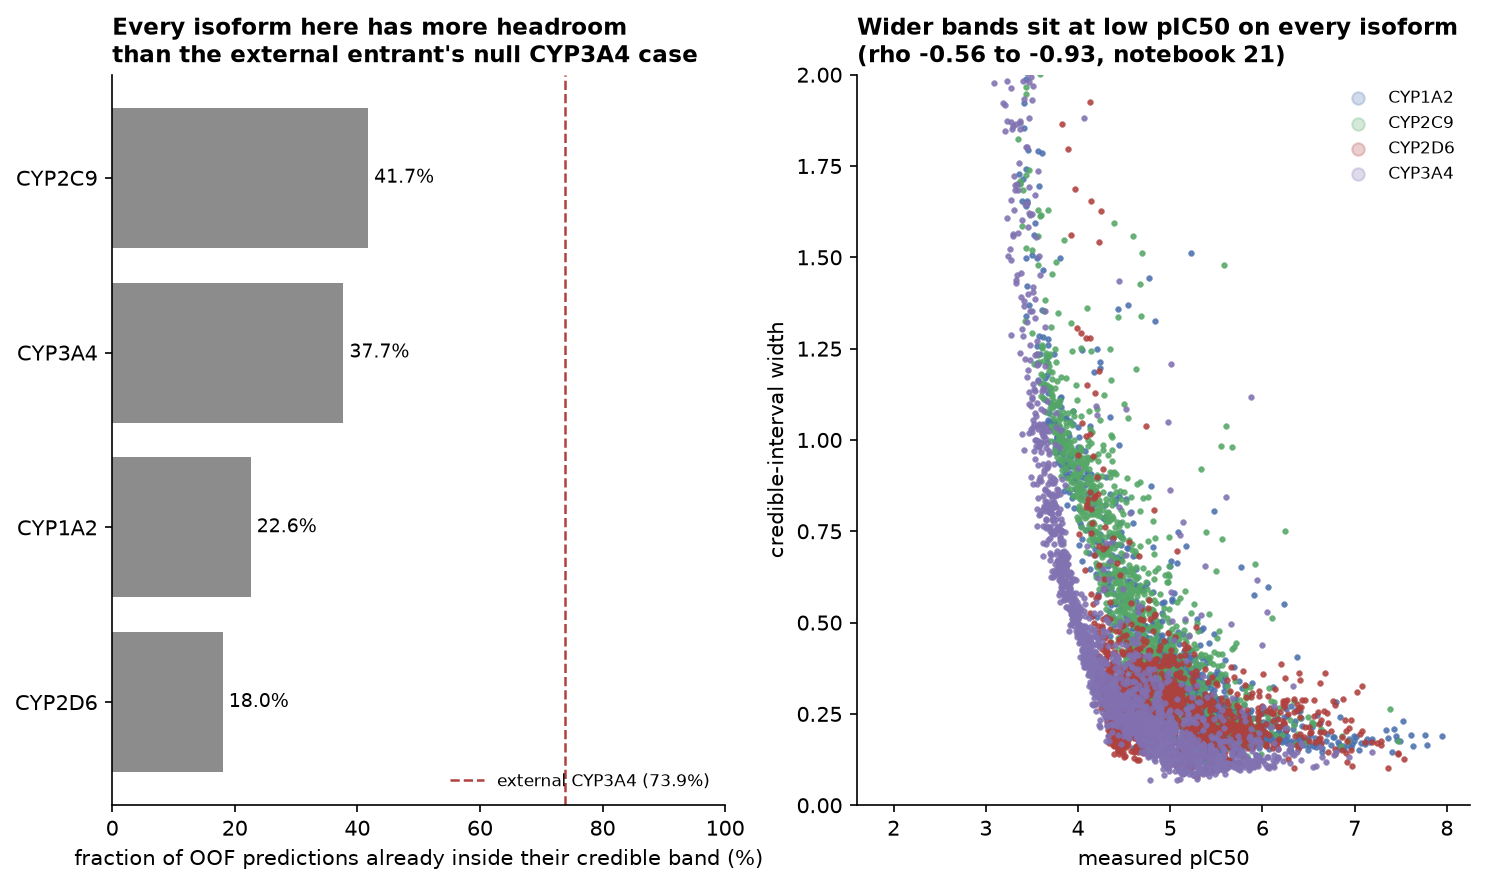

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/figures/band_hit_rate_by_isoform.png


In [6]:
BASELINE_COLOR = "#8C8C8C"
DEADZONE_COLOR = "#B0413E"

plt.rcParams["font.size"] = 10
fig, axes = plt.subplots(1, 2, figsize=(10, 6), dpi=150)

# Panel A -- hit rate by isoform
ax = axes[0]
order = headroom_df.sort_values("hit_rate_inside_band")["isoform"].tolist()
vals = headroom_df.set_index("isoform").loc[order, "hit_rate_inside_band"] * 100
bars = ax.barh(order, vals, color=BASELINE_COLOR)
for b, v in zip(bars, vals):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9)
ax.axvline(73.9, color=DEADZONE_COLOR, linestyle="--", linewidth=1.2, label="external CYP3A4 (73.9%)")
ax.set_xlabel("fraction of OOF predictions already inside their credible band (%)")
ax.set_xlim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title("Every isoform here has more headroom\nthan the external entrant's null CYP3A4 case",
             fontsize=11, fontweight="bold", loc="left")

# Panel B -- band width vs pIC50 (scatter, one isoform, representative), all isoforms as small multiples via color
ax = axes[1]
colors = {"CYP1A2": "#4C72B0", "CYP2C9": "#55A868", "CYP2D6": DEADZONE_COLOR, "CYP3A4": "#8172B2"}
for iso in ISOFORMS:
    oof = oof_tables[iso]
    width = oof["conf_high"] - oof["conf_low"]
    ax.scatter(oof["y_true"], width, s=4, alpha=0.25, color=colors[iso], label=iso, rasterized=True)
ax.set_xlabel("measured pIC50")
ax.set_ylabel("credible-interval width")
ax.set_ylim(0, 2.0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
leg = ax.legend(frameon=False, fontsize=8, loc="upper right", markerscale=3)
ax.set_title("Wider bands sit at low pIC50 on every isoform\n(rho -0.56 to -0.93, notebook 21)",
             fontsize=11, fontweight="bold", loc="left")

fig.tight_layout()
fig.savefig(FIG_OUT / "band_hit_rate_by_isoform.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {FIG_OUT / 'band_hit_rate_by_isoform.png'}")

**Figure 1.** Left: fraction of `chemprop_chemeleoninit`'s pooled out-of-fold predictions
(25-fold, `outputs/11_caruana_prep/`) that already sit inside their compound's own published
credible band, per isoform — the quantity that upper-bounds what the dead-zone target can
possibly change, since `clip(p) = p` wherever the model already lands inside the band. All four
isoforms sit well below the external entrant's own reported CYP3A4 saturation point (dashed
line), the case they used to explain why CYP3A4 showed no gain under this same intervention on
their own pipeline. Right: credible-interval width against measured pIC50 for every OOF row,
all four isoforms overlaid — wide bands concentrate at low potency on every isoform (Spearman
−0.56 to −0.93, cross-checked against notebook 21's own stored figure above), the structural
precondition for a dead-zone target to have room to act asymmetrically.

## Part 1 — Pre-registration, frozen before any training

Frozen to `outputs/31_deadzone/prereg.json` before the first `chemprop train` call anywhere in
this notebook.

In [7]:
PREREG = {
    "notebook": "31_deadzone",
    "frozen_at_utc": datetime.now(timezone.utc).isoformat(),
    "frozen_before": "any chemprop train call in this notebook",
    "mechanism": (
        "Replace the training TARGET with clip(oof_prediction, conf_low, conf_high) under "
        "absolute-error loss ('mae' in chemprop's LossFunctionRegistry, confirmed against the "
        "installed chemprop 2.3.1 API to compute |pred - target| exactly -- see the loss-function "
        "verification cell below). A prediction already inside its own band gets zero gradient; "
        "a prediction outside gets pulled toward the nearest edge, not the point estimate."
    ),
    "interpretation_rules": {
        "resolved_against": "BASELINE's own 3-seed ST-RAE standard deviation (ddof=1) on that isoform",
        "IMPROVES": "an arm's mean ST-RAE is lower than BASELINE's by MORE than BASELINE's own 3-seed spread",
        "TIES": (
            "absolute difference smaller than that spread. Per notebooks 18, 20, 26 and 29 this "
            "MUST be reported as UNRESOLVED, never as 'a small gain' or 'a small loss'."
        ),
        "HURTS": "an arm's mean ST-RAE is higher than BASELINE's by more than that spread",
    },
    "part0_headroom_predictions": {
        "hit_rate_ordering_most_to_least_headroom": ["CYP2D6", "CYP1A2", "CYP3A4", "CYP2C9"],
        "hit_rates": headroom_df.set_index("isoform")["hit_rate_inside_band"].round(4).to_dict(),
        "note": (
            "All four hit rates (18.0-41.7%) sit well below the external entrant's own reported "
            "CYP3A4 saturation point (73.9%) -- a null result here would be a cleaner negative "
            "than the external CYP3A4 case, not explained by 'nothing left to win'. CYP2D6 and "
            "CYP1A2 have the most headroom on this project's own numbers; CYP2C9 has the least, "
            "in some tension with the external entrant's own per-isoform gain ordering, which "
            "puts CYP2C9 second-largest -- flagged now, checked against the real result in Part 3."
        ),
        "cyp2d6_caveat": (
            "Notebook 21 established OOF ST-RAE is not a valid selection metric for CYP2D6, and "
            "the board has contradicted OOF evidence for that isoform twice. Any CYP2D6 movement "
            "here, in either direction, carries this caveat undiminished."
        ),
    },
    "submission_bar": {
        "rule": (
            "A full-data retrain and submission candidate (Part 4) is built ONLY IF the DEADZONE "
            "arm IMPROVES on at least two isoforms AND does not HURT on any isoform. "
            "DEADZONE+AID (arm 3) is diagnostic only and is NEVER itself a submission candidate "
            "under any result -- see 'arm3_scope' below."
        ),
        "frozen_before_any_training": True,
        "may_not_be_adjusted_after_results": True,
    },
    "decorrelation_secondary_outcome": {
        "context": (
            "Notebook 24 established this project's 11-config pool sits at error correlation "
            "0.79-0.91 (prediction-minus-truth, not raw prediction, per Dietterich 2000 -- this "
            "project's CLAUDE.md rule). Notebook 29 found the AID auxiliary-head model at "
            "0.850-0.933 against the same baseline -- also not decorrelated. A dead-zone model "
            "optimises a genuinely different objective (absolute error against a clipped, "
            "non-affine-transformed target), which is the kind of difference the working external "
            "entrants report using."
        ),
        "rule": (
            "Report error correlation (prediction - truth) between each arm and BASELINE, per "
            "isoform, with baseline-seed-vs-baseline-seed as the floor (notebook 29's method). "
            "This is its OWN verdict, separate from the ST-RAE IMPROVES/TIES/HURTS call -- a TIE "
            "on ST-RAE with genuine decorrelation (below the 0.79-0.91 pool band and below the "
            "baseline-seed floor) would still be an informative, reportable result."
        ),
    },
    "arm3_scope": (
        "DEADZONE+AID (notebook 28/29's 21,364-row, 8-head AID-augmented table, dead-zone target "
        "applied to the 4 scored heads only) answers whether the dead-zone and AID-auxiliary-head "
        "mechanisms compose. It is diagnostic only. It is NOT a submission candidate under any "
        "result in this task, and no full-data AID retrain is performed under any result."
    ),
    "loss_function": "PENDING -- confirmed against the installed chemprop API in the next section",
    "seeds": "PENDING -- set in the next section",
    "epochs": 50,
    "patience": 5,
    "honest_prior": (
        "Eight prior modelling screens on this project came back flat, reversed at full CV, or "
        "reversed on the real board. A null result here is a legitimate and likely outcome."
    ),
    "scope": (
        "Report on the screen (Part 0-3). Part 4 (full-data retrain + submission candidate, "
        "DEADZONE arm only, never sent) executes ONLY if the submission_bar above is met. No "
        "25-fold CV, no ensemble, no AID full-data retrain, no submission sent, under any result."
    ),
}

PREREG_PATH = OUT / "prereg.json"
with open(PREREG_PATH, "w") as f:
    json.dump(PREREG, f, indent=2, default=float)
print(f"FROZEN -> {PREREG_PATH}")
print()
print(json.dumps(PREREG["submission_bar"], indent=2))

FROZEN -> /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/prereg.json

{
  "rule": "A full-data retrain and submission candidate (Part 4) is built ONLY IF the DEADZONE arm IMPROVES on at least two isoforms AND does not HURT on any isoform. DEADZONE+AID (arm 3) is diagnostic only and is NEVER itself a submission candidate under any result -- see 'arm3_scope' below.",
  "frozen_before_any_training": true,
  "may_not_be_adjusted_after_results": true
}


## Part 2 — The screen: three arms, one fold, three seeds

`BASELINE` (point-estimate target, default loss), `DEADZONE` (clipped target, absolute-error
loss), `DEADZONE+AID` (clipped target on the 4 scored heads + notebook 28/29's 4 AID auxiliary
heads, same absolute-error loss applied uniformly across all 8 heads — chemprop's `--loss-function`
is a single, per-run criterion, not settable per head, stated here as a real consequence: this
also changes the AID auxiliary heads' own loss from notebooks 28/29's implicit MSE to MAE, an
unavoidable side effect of composing the two mechanisms in one run, not a separate design choice).

Same fold as notebooks 04a/06/18/20/22/28/29 (`repeat_0`, `fold=0` of the existing
`data/folds/cv_folds.csv` — not a new split), same three seeds as notebooks 18/20/22/28/29.
`src/chemprop_screen.py` reused unmodified.

In [8]:
import os
import subprocess

from src.features import assign_screen_split
from src.chemprop_screen import (
    build_predict_csv,
    build_training_csv,
    load_screen_population,
    run_chemprop_predict,
    run_chemprop_train,
    setup_logging,
    verify_predictions,
)

_env_bin = str(Path(sys.executable).parent)
_parts = os.environ.get("PATH", "").split(os.pathsep)
if _env_bin not in _parts:
    os.environ["PATH"] = os.pathsep.join([_env_bin, *_parts])
print(f"chemprop on PATH: {subprocess.run(['which', 'chemprop'], capture_output=True, text=True).stdout.strip()}")

FOLDS_PATH = REPO_ROOT / "data" / "folds" / "cv_folds.csv"
STORED_05_SCORE_PATH = REPO_ROOT / "outputs" / "05_cv_comparison" / "scores" / "chemprop_chemeleoninit__repeat0_fold0.csv"

CHEMPROP_RUNS_DIR = OUT / "chemprop_runs"
PRED_DIR = OUT / "predictions"
SCORE_DIR = OUT / "scores"
LOG_DIR = REPO_ROOT / "logs" / "31_deadzone"
for d in [CHEMPROP_RUNS_DIR, PRED_DIR, SCORE_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REPEAT_COL = "repeat_0"
TEST_FOLD = 0
VAL_FRACTION = 0.15

# Same three seeds as notebooks 18/20/22/28/29.
SEEDS = [2684470948, 4091952314, 233227757]

EPOCHS = 50
PATIENCE = 5
CHEMELEON_ARCH_ARGS = ["--from-foundation", "CHEMELEON", "--multi-hot-atom-featurizer-mode", "V2"]

print(f"seeds: {SEEDS}")
print(f"fold: {REPEAT_COL}, test_fold={TEST_FOLD}, val_fraction={VAL_FRACTION}")
print(f"epochs={EPOCHS}, patience={PATIENCE}")

chemprop on PATH: /Users/codiefreeman/miniconda3-arm64/envs/cyp-admet-v2/bin/chemprop
seeds: [2684470948, 4091952314, 233227757]
fold: repeat_0, test_fold=0, val_fraction=0.15
epochs=50, patience=5


### Loss function — confirmed against the installed chemprop 2.3.1 API, not assumed

`chemprop train --help` lists `mae` as a valid `--loss-function` / `-l` choice. Confirmed directly
against the installed package's own class below (not just the CLI help text) that this computes
plain `|pred - target|` — exactly the absolute-error loss this task specifies, no bounded/robust
variant substituted.

In [9]:
import chemprop.nn as cp_nn

mae_loss_cls = cp_nn.LossFunctionRegistry["mae"]
mae_source = inspect.getsource(mae_loss_cls)
print(f"chemprop.nn.LossFunctionRegistry['mae'] -> {mae_loss_cls}")
print(mae_source)
_normalized = mae_source.replace(" ", "")
assert "(preds-targets).abs()" in _normalized, \
    "unexpected mae loss implementation -- stopping rather than assuming"
print("CONFIRMED: chemprop's 'mae' loss computes (preds - targets).abs() -- plain absolute-error loss.")

default_regression_criterion = cp_nn.PredictorRegistry["regression"]._T_default_criterion
print(f"\ndefault regression-task criterion (used when --loss-function is omitted): {default_regression_criterion}")
assert default_regression_criterion is cp_nn.LossFunctionRegistry["mse"], "regression default is not MSE -- check assumption"
print("CONFIRMED: chemprop's default regression loss is MSE -- BASELINE is given --loss-function mse")
print("explicitly below (rather than relying on the default) so both arms' loss choice is stated,")
print("not implicit.")

LOSS_ARGS = {
    "baseline": ["--loss-function", "mse"],
    "deadzone": ["--loss-function", "mae"],
    "deadzone_aid": ["--loss-function", "mae"],
    "mae_only": ["--loss-function", "mae"],
}
ARCH_ARGS = {
    "baseline": CHEMELEON_ARCH_ARGS + LOSS_ARGS["baseline"],
    "deadzone": CHEMELEON_ARCH_ARGS + LOSS_ARGS["deadzone"],
    "deadzone_aid": CHEMELEON_ARCH_ARGS + LOSS_ARGS["deadzone_aid"],
    "mae_only": CHEMELEON_ARCH_ARGS + LOSS_ARGS["mae_only"],
}
for arm, args in ARCH_ARGS.items():
    print(f"  {arm:14s}: {args}")

# Freeze the loss function and seeds into prereg.json now that they're confirmed.
PREREG["loss_function"] = {
    "baseline": "mse (chemprop default for task-type regression, set explicitly)",
    "deadzone": "mae (confirmed via chemprop.nn.LossFunctionRegistry['mae'] source: (preds-targets).abs())",
    "deadzone_aid": "mae, applied to all 8 heads uniformly -- chemprop's --loss-function is one criterion per run, not per head",
    "mae_only": (
        "mae, on the RAW point-estimate target (no OOF clipping) -- added as a diagnostic arm "
        "AFTER the initial 3-arm result was seen (not pre-registered blind), at the user's "
        "explicit direction, specifically to decompose the loss-function-vs-target confound: "
        "DEADZONE changes both the loss (mse->mae) and the target (point estimate -> OOF-clipped) "
        "relative to BASELINE simultaneously, so the initial screen alone cannot say how much of "
        "its gain is attributable to each. mae_only isolates the loss-function effect alone. "
        "Stated explicitly, not hidden: this arm's own verdict is NOT blind to DEADZONE's result."
    ),
}
PREREG["seeds"] = SEEDS
with open(PREREG_PATH, "w") as f:
    json.dump(PREREG, f, indent=2, default=float)
print(f"\nRE-FROZEN (loss_function + seeds added) -> {PREREG_PATH}")

chemprop.nn.LossFunctionRegistry['mae'] -> <class 'chemprop.nn.metrics.MAE'>
@MetricRegistry.register("mae")
@LossFunctionRegistry.register("mae")
class MAE(ChempropMetric):
    def _calc_unreduced_loss(self, preds, targets, *args) -> Tensor:
        return (preds - targets).abs()

CONFIRMED: chemprop's 'mae' loss computes (preds - targets).abs() -- plain absolute-error loss.

default regression-task criterion (used when --loss-function is omitted): <class 'chemprop.nn.metrics.MSE'>
CONFIRMED: chemprop's default regression loss is MSE -- BASELINE is given --loss-function mse
explicitly below (rather than relying on the default) so both arms' loss choice is stated,
not implicit.
  baseline      : ['--from-foundation', 'CHEMELEON', '--multi-hot-atom-featurizer-mode', 'V2', '--loss-function', 'mse']
  deadzone      : ['--from-foundation', 'CHEMELEON', '--multi-hot-atom-featurizer-mode', 'V2', '--loss-function', 'mae']
  deadzone_aid  : ['--from-foundation', 'CHEMELEON', '--multi-hot-atom-

### Building the dead-zone target — from out-of-fold predictions, never in-fold

**This is the trap this task exists to avoid.** The target for every training-pool compound is
built from `chemprop_chemeleoninit`'s pooled OOF prediction at `repeat=0` in
`outputs/11_caruana_prep/oof_long_{iso}.csv` — i.e. for each compound, the prediction made by
whichever of `05`'s 5 fold-models did NOT have that compound in its own training set. Within one
repeat, every labeled compound appears exactly once (held out by exactly one of that repeat's 5
folds), so filtering `oof_long` to `repeat == 0` gives one genuinely out-of-fold prediction per
labeled compound — never a compound's own training-time prediction, and in particular never a
prediction from a model that had this exact screen's own fold-0/1-4 split in mind (a strictly
weaker, more defensible property than merely "not this notebook's own model").

`curated`'s raw point estimates are used for BASELINE and for scoring truth throughout (never
overwritten). A separate `curated_deadzone` copy has each scored endpoint column replaced by
`clip(oof_prediction, conf_low, conf_high)` — this is what DEADZONE and DEADZONE+AID train
against.

In [10]:
curated = pd.read_csv(CURATED_PATH)
print(f"loaded {CURATED_PATH.name}: {curated.shape}")

curated_deadzone = curated.copy()
coverage_rows = []
for iso in ISOFORMS:
    endpoint = PIC50_COL[iso]
    oof_r0 = oof_tables[iso][oof_tables[iso]["repeat"] == 0][["inchikey", "chemprop_chemeleoninit"]]
    oof_r0 = oof_r0.rename(columns={"chemprop_chemeleoninit": "_oof_pred"})
    n_labeled = int(curated[endpoint].notna().sum())
    assert len(oof_r0) == n_labeled, (
        f"{iso}: repeat-0 OOF row count ({len(oof_r0)}) != labeled compound count in curated "
        f"({n_labeled}) -- coverage mismatch, stop before building any target."
    )
    assert oof_r0["inchikey"].is_unique, f"{iso}: duplicate inchikey in repeat-0 OOF slice"

    merged = curated[["inchikey", endpoint,
                       f"{endpoint}_conf_low", f"{endpoint}_conf_high"]].merge(
        oof_r0, on="inchikey", how="left"
    )
    assert len(merged) == len(curated), "merge changed row count"
    assert merged["inchikey"].tolist() == curated["inchikey"].tolist(), (
        "left-merge did not preserve curated's row order -- positional assignment below would "
        "silently misalign rows. Stopping rather than assuming pandas' default ordering behaviour."
    )
    # Every labeled row must have picked up an OOF prediction; every unlabeled row must not.
    has_label = merged[endpoint].notna()
    has_oof = merged["_oof_pred"].notna()
    assert (has_label == has_oof).all(), f"{iso}: labeled/OOF-coverage mismatch after merge"

    clipped = merged["_oof_pred"].clip(lower=merged[f"{endpoint}_conf_low"], upper=merged[f"{endpoint}_conf_high"])
    curated_deadzone[endpoint] = clipped.to_numpy()

    coverage_rows.append({
        "isoform": iso, "n_labeled": n_labeled, "n_oof_matched": int(has_oof.sum()),
        "n_target_changed": int((has_label & (clipped.to_numpy() != curated[endpoint].to_numpy())).sum()),
    })
    print(f"{iso}: {n_labeled} labeled rows, {int(has_oof.sum())} OOF-matched, "
          f"target replaced on {coverage_rows[-1]['n_target_changed']} rows")

coverage_df = pd.DataFrame(coverage_rows)
print()
print(coverage_df.to_string(index=False))
assert (coverage_df["n_labeled"] == coverage_df["n_oof_matched"]).all(), "coverage gap -- stop"
assert (coverage_df["n_target_changed"] == coverage_df["n_labeled"]).all(), (
    "IDENTITY-FAILURE CHECK: the deadzone target equals the raw point estimate on every labeled "
    "row for at least one isoform -- this is the exact trap this task warns about. STOPPING."
)
print("\nCONFIRMED: the dead-zone target differs from the raw point-estimate label on every")
print("single labeled row, all four isoforms -- built from genuine repeat-0 OOF predictions,")
print("never from an in-fold/overfit prediction and never accidentally equal to the raw label.")

loaded train_inhibition_curated.csv: (4905, 20)
CYP1A2: 1412 labeled rows, 1412 OOF-matched, target replaced on 1412 rows
CYP2C9: 1285 labeled rows, 1285 OOF-matched, target replaced on 1285 rows
CYP2D6: 1493 labeled rows, 1493 OOF-matched, target replaced on 1493 rows
CYP3A4: 2335 labeled rows, 2335 OOF-matched, target replaced on 2335 rows

isoform  n_labeled  n_oof_matched  n_target_changed
 CYP1A2       1412           1412              1412
 CYP2C9       1285           1285              1285
 CYP2D6       1493           1493              1493
 CYP3A4       2335           2335              2335

CONFIRMED: the dead-zone target differs from the raw point-estimate label on every
single labeled row, all four isoforms -- built from genuine repeat-0 OOF predictions,
never from an in-fold/overfit prediction and never accidentally equal to the raw label.


### Building the per-seed populations

`load_screen_population` (unmodified, `src/chemprop_screen.py`) is used for BASELINE directly off
`CURATED_PATH`. For DEADZONE, `curated_deadzone` is written to its own CSV first (same schema as
`train_inhibition_curated.csv`) so the identical, unmodified `load_screen_population` function can
be reused rather than re-implementing its split/merge/logging logic — the only difference is which
file it reads.

In [11]:
CURATED_DEADZONE_PATH = OUT / "curated_deadzone_target.csv"
curated_deadzone.to_csv(CURATED_DEADZONE_PATH, index=False)
print(f"wrote {CURATED_DEADZONE_PATH} ({curated_deadzone.shape})")

logger_setup = setup_logging(LOG_DIR / "population_setup.log", "nb31_population_setup")

baseline_populations = {}
deadzone_populations = {}
for seed in SEEDS:
    baseline_populations[seed] = load_screen_population(
        FOLDS_PATH, CURATED_PATH, REPEAT_COL, TEST_FOLD, VAL_FRACTION, seed, logger_setup
    )
    deadzone_populations[seed] = load_screen_population(
        FOLDS_PATH, CURATED_DEADZONE_PATH, REPEAT_COL, TEST_FOLD, VAL_FRACTION, seed, logger_setup
    )

for seed in SEEDS:
    a = baseline_populations[seed]["screen_split"].value_counts().to_dict()
    b = deadzone_populations[seed]["screen_split"].value_counts().to_dict()
    print(f"seed {seed}: baseline split={a}  deadzone split={b}")
    assert a == b, f"split counts differ between baseline/deadzone at seed {seed}"

print("\nCONFIRMED: identical screen_split composition between BASELINE and DEADZONE at every seed")
print("(both are built from assign_screen_split with identical arguments -- only the target VALUES")
print("differ, never the split membership).")

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/curated_deadzone_target.csv ((4905, 20))
2026-09-19 13:12:42,269 [INFO] loaded cv_folds.csv: (4905, 7)


2026-09-19 13:12:42,270 [INFO] loaded train_inhibition_curated.csv: (4905, 20)


2026-09-19 13:12:42,277 [INFO] assign_screen_split(repeat_col='repeat_0', test_fold=0, val_fraction=0.15, seed=2684470948) split counts: {'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}


2026-09-19 13:12:42,279 [INFO] rows after SMILES/target join: 4905 (missing: 0)


2026-09-19 13:12:42,280 [INFO]   CYP1A2_pIC50_direct_inhibition: labeled-compound counts per split = {'screen_inner_train': 975, 'screen_inner_val': 160, 'screen_test': 277}


...

2026-09-19 13:12:42,377 [INFO]   CYP1A2_pIC50_direct_inhibition: labeled-compound counts per split = {'screen_inner_train': 965, 'screen_inner_val': 170, 'screen_test': 277}


2026-09-19 13:12:42,378 [INFO]   CYP2C9_pIC50_direct_inhibition: labeled-compound counts per split = {'screen_inner_train': 864, 'screen_inner_val': 157, 'screen_test': 264}


2026-09-19 13:12:42,379 [INFO]   CYP2D6_pIC50_direct_inhibition: labeled-compound counts per split = {'screen_inner_train': 1041, 'screen_inner_val': 157, 'screen_test': 295}


2026-09-19 13:12:42,380 [INFO]   CYP3A4_pIC50_direct_inhibition: labeled-compound counts per split = {'screen_inner_train': 1587, 'screen_inner_val': 298, 'screen_test': 450}


seed 2684470948: baseline split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}  deadzone split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
seed 4091952314: baseline split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}  deadzone split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}
seed 233227757: baseline split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}  deadzone split={'screen_inner_train': 3335, 'screen_test': 981, 'screen_inner_val': 589}

CONFIRMED: identical screen_split composition between BASELINE and DEADZONE at every seed
(both are built from assign_screen_split with identical arguments -- only the target VALUES
differ, never the split membership).


### ARM 3 (DEADZONE+AID) — rebuilding notebook 28/29's augmented table, dead-zoned

Reuses, read-only: `outputs/28_external_data/aid1851_max_response.csv` (the already re-derived
efficacy readout — notebook 28's own recovery of `Max_Response` from the raw AID 1851 batches,
which `aid1851_curated.csv` itself dropped at curation) and `data/processed/aid1851_curated.csv`
(notebook 13's curated AID 1851 population, for `canonical_smiles`/compound identity). This
reproduces notebook 28 cells 34–39's own construction exactly (same pivot, same left-merge-outward
pattern, same blind-set exclusion, same "extras always `screen_inner_train`" rule) — the only
change is that the curated part's 4 scored endpoint columns come from `curated_deadzone`, not
`curated`, before the extra 16,459 AID-only rows (which carry no scored label regardless) are
appended.

In [12]:
AID_CURATED_PATH = REPO_ROOT / "data" / "processed" / "aid1851_curated.csv"
AID_MAXRESP_CACHE = REPO_ROOT / "outputs" / "28_external_data" / "aid1851_max_response.csv"  # READ-ONLY
BLIND_PATH = REPO_ROOT / "data" / "processed" / "test_blinded_curated.csv"

aid_curated = pd.read_csv(AID_CURATED_PATH)
aid_eff = pd.read_csv(AID_MAXRESP_CACHE)
print(f"aid1851_curated.csv: {aid_curated.shape}  |  cached max_response: {aid_eff.shape}")

aid_eff["max_inhibition"] = -aid_eff["max_response"]
aid = aid_curated.merge(
    aid_eff[["inchikey", "isoform", "max_response", "max_inhibition"]], on=["inchikey", "isoform"], how="inner"
)
assert len(aid) == len(aid_curated), "join changed row count -- stop"

blind = pd.read_csv(BLIND_PATH)
blind_ik = set(blind["inchikey"].dropna())
n0 = len(aid)
aid = aid[~aid["inchikey"].isin(blind_ik)].copy()
print(f"excluded blind-set compounds: {n0} -> {len(aid)} rows")
assert len(set(aid["inchikey"]) & blind_ik) == 0, "a blind compound survived exclusion -- stop"

AUX_COLS = [f"{iso}_AID1851_max_inhibition" for iso in ISOFORMS]
aid_wide = aid.pivot(index="inchikey", columns="isoform", values="max_inhibition")
aid_wide.columns = [f"{c}_AID1851_max_inhibition" for c in aid_wide.columns]
aid_wide = aid_wide.reset_index()
aid_wide = aid_wide.merge(aid[["inchikey", "canonical_smiles"]].drop_duplicates("inchikey"), on="inchikey", how="left")
aid_wide = aid_wide[["inchikey", "canonical_smiles"] + AUX_COLS]
assert aid_wide["inchikey"].is_unique
print(f"AID wide table: {aid_wide.shape}")

BASE_COLS = ["Molecule_Name", "inchikey", "canonical_smiles"]
curated_ik = set(curated["inchikey"].dropna())

# Curated part -- scored endpoints from curated_deadzone (NOT curated), aux columns attached.
curated_part = curated_deadzone[BASE_COLS + REGRESSION_ENDPOINTS].copy()
n_before = len(curated_part)
curated_part = curated_part.merge(aid_wide[["inchikey"] + AUX_COLS], on="inchikey", how="left")
assert len(curated_part) == n_before, "merge changed row count -- duplicate inchikey somewhere"
n_attached = int(curated_part[AUX_COLS].notna().any(axis=1).sum())
print(f"curated rows: {len(curated_part)}, carrying attached AID values: {n_attached}")

extra_part = aid_wide[~aid_wide["inchikey"].isin(curated_ik)].copy()
extra_part["Molecule_Name"] = "AID1851_" + extra_part["inchikey"]
for c in REGRESSION_ENDPOINTS:
    extra_part[c] = np.nan
extra_part = extra_part[BASE_COLS + REGRESSION_ENDPOINTS + AUX_COLS]
print(f"AID-only extra rows: {len(extra_part)}")

FULL_POP_DEADZONE = pd.concat([curated_part, extra_part], ignore_index=True)
assert FULL_POP_DEADZONE["inchikey"].is_unique
assert FULL_POP_DEADZONE["Molecule_Name"].is_unique
assert FULL_POP_DEADZONE["canonical_smiles"].notna().all()
EXTRA_IK = set(extra_part["inchikey"])
print(f"\nFULL_POP_DEADZONE: {FULL_POP_DEADZONE.shape}  |  extra (AID-only) compounds: {len(EXTRA_IK)}")
assert FULL_POP_DEADZONE.shape[0] == 21364, f"expected 21364 rows (notebooks 28/29's own figure), got {FULL_POP_DEADZONE.shape[0]}"
print("CONFIRMED: 21,364 rows, matching notebooks 28/29's own construction exactly.")

aid1851_curated.csv: (66232, 6)  |  cached max_response: (66232, 4)
excluded blind-set compounds: 66232 -> 66228 rows


AID wide table: (16557, 6)


curated rows: 4905, carrying attached AID values: 98

AID-only extra rows: 16459



FULL_POP_DEADZONE: (21364, 11)  |  extra (AID-only) compounds: 16459
CONFIRMED: 21,364 rows, matching notebooks 28/29's own construction exactly.


### Winsorisation — recomputed fresh on this fold's training portion, cross-checked

Same rule as notebooks 28/29: clip each `*_AID1851_max_inhibition` column to its 1st/99th
percentile, computed on training-portion rows only (everything not in `screen_test`, i.e. not
`repeat_0`'s fold 0 — seed-independent). Recomputed here rather than reused, then cross-checked
against notebook 28's own frozen bounds (`outputs/28_external_data/prereg.json`, read-only) —
identical fold, so identical training-portion compounds, so the two should match to `1e-8`
exactly (notebook 29's own precedent for this cross-check).

In [13]:
cv_folds = pd.read_csv(FOLDS_PATH)
TEST_IK = set(cv_folds.loc[cv_folds[REPEAT_COL] == TEST_FOLD, "inchikey"])
train_portion_mask = ~FULL_POP_DEADZONE["inchikey"].isin(TEST_IK)
print(f"training-portion rows for winsorisation bounds: {int(train_portion_mask.sum())} of {len(FULL_POP_DEADZONE)}")

WINSOR_LOW_PCT, WINSOR_HIGH_PCT = 1.0, 99.0
winsor_bounds = {}
for c in AUX_COLS:
    vals = FULL_POP_DEADZONE.loc[train_portion_mask, c].dropna()
    lo = float(np.percentile(vals, WINSOR_LOW_PCT))
    hi = float(np.percentile(vals, WINSOR_HIGH_PCT))
    winsor_bounds[c] = {"low": lo, "high": hi, "n_train_portion_nonnull": int(len(vals))}
    FULL_POP_DEADZONE[c] = FULL_POP_DEADZONE[c].clip(lower=lo, upper=hi)
    print(f"  {c:40s} p01={lo:9.3f}  p99={hi:9.3f}  n={len(vals)}")

with open(REPO_ROOT / "outputs" / "28_external_data" / "prereg.json") as f:
    nb28_prereg = json.load(f)
nb28_bounds = nb28_prereg["winsorisation"]["bounds"]
max_bound_diff = 0.0
for c in AUX_COLS:
    d_lo = abs(winsor_bounds[c]["low"] - nb28_bounds[c]["low"])
    d_hi = abs(winsor_bounds[c]["high"] - nb28_bounds[c]["high"])
    max_bound_diff = max(max_bound_diff, d_lo, d_hi)
print(f"\nmax abs diff vs. notebook 28's own frozen winsorisation bounds: {max_bound_diff:.2e}")
assert max_bound_diff < 1e-8, "winsorisation bounds do not reproduce notebook 28's own numbers -- stop"
print("CONFIRMED: identical to notebook 28's own frozen bounds -- same fold, same training-portion")
print("compounds, as expected.")

training-portion rows for winsorisation bounds: 20383 of 21364
  CYP1A2_AID1851_max_inhibition            p01=  -13.206  p99=  116.293  n=16529
  CYP2C9_AID1851_max_inhibition            p01= -184.327  p99=  121.182  n=16529


  CYP2D6_AID1851_max_inhibition            p01=  -29.330  p99=  100.348  n=16529
  CYP3A4_AID1851_max_inhibition            p01=  -74.892  p99=  108.126  n=16529

max abs diff vs. notebook 28's own frozen winsorisation bounds: 0.00e+00
CONFIRMED: identical to notebook 28's own frozen bounds -- same fold, same training-portion
compounds, as expected.


In [14]:
def build_augmented_population(full_pop, cv_folds, repeat_col, test_fold, val_fraction, seed):
    # Reused from notebook 28 cell 39, unmodified logic: extras are absent from cv_folds.csv
    # (NaN screen_split after the merge) and always assigned screen_inner_train.
    split_df = assign_screen_split(cv_folds, repeat_col=repeat_col, test_fold=test_fold,
                                    val_fraction=val_fraction, seed=seed)
    pop = full_pop.merge(split_df[["inchikey", "screen_split"]], on="inchikey", how="left")
    assert len(pop) == len(full_pop), "merge changed row count"
    is_extra_row = pop["screen_split"].isna()
    pop.loc[is_extra_row, "screen_split"] = "screen_inner_train"
    assert pop["screen_split"].isin(["screen_test", "screen_inner_train", "screen_inner_val"]).all()
    return pop


deadzone_aid_populations = {}
for seed in SEEDS:
    deadzone_aid_populations[seed] = build_augmented_population(
        FULL_POP_DEADZONE, cv_folds, REPEAT_COL, TEST_FOLD, VAL_FRACTION, seed
    )
    held = set(deadzone_aid_populations[seed].loc[
        deadzone_aid_populations[seed]["screen_split"] == "screen_test", "inchikey"])
    assert held.isdisjoint(EXTRA_IK), f"an extra compound was held out at seed {seed}"
    inner_val = set(deadzone_aid_populations[seed].loc[
        deadzone_aid_populations[seed]["screen_split"] == "screen_inner_val", "inchikey"])
    assert inner_val.isdisjoint(EXTRA_IK), f"an extra compound landed in screen_inner_val at seed {seed}"
    print(f"seed {seed}: deadzone_aid split = "
          f"{deadzone_aid_populations[seed]['screen_split'].value_counts().to_dict()}")

print("\nCONFIRMED: no extra (AID-only) compound is ever held out or placed in the validation set,")
print("at any seed.")

seed 2684470948: deadzone_aid split = {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}


seed 4091952314: deadzone_aid split = {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}


seed 233227757: deadzone_aid split = {'screen_inner_train': 19794, 'screen_test': 981, 'screen_inner_val': 589}

CONFIRMED: no extra (AID-only) compound is ever held out or placed in the validation set,
at any seed.


### Cross-arm assertions — the held-out set and scored labels must agree everywhere

Before any training: the held-out (`screen_test`) compound set must be byte-identical across all
three arms and all three seeds (only the training-side target values differ between arms), and
the raw curated labels used for scoring (never the training targets) must never be touched by
anything above.

In [15]:
TOL = 1e-8
print("CHECK 1 -- held-out set identical across all 3 arms and all 3 seeds")
ref_test = None
for arm_name, pops in [("baseline", baseline_populations), ("deadzone", deadzone_populations),
                       ("deadzone_aid", deadzone_aid_populations)]:
    for seed in SEEDS:
        pop = pops[seed]
        t = pop.loc[pop["screen_split"] == "screen_test", "Molecule_Name"].sort_values().tolist()
        if ref_test is None:
            ref_test = t
            print(f"  reference: {arm_name} seed {seed} -- {len(t)} compounds")
        else:
            assert t == ref_test, f"held-out set differs for {arm_name} seed {seed}"
print(f"  PASS: all 9 (arm, seed) combinations hold out the identical {len(ref_test)} compounds.")

print("\nCHECK 2 -- curated (raw, scoring) labels are untouched by any of the above")
_curated_reread = pd.read_csv(CURATED_PATH)
_diff = np.nanmax(np.abs(
    _curated_reread[REGRESSION_ENDPOINTS].to_numpy(dtype=float) - curated[REGRESSION_ENDPOINTS].to_numpy(dtype=float)
))
_diff = 0.0 if np.isnan(_diff) else float(_diff)
print(f"  max abs diff between in-memory `curated` and a fresh re-read of disk: {_diff:.2e}")
assert _diff < TOL, "curated (raw labels) appears to have been mutated in-memory -- stop"
print("  PASS")

print("\nCHECK 3 -- no blind-750 compound anywhere in any training population")
n_blind_in_deadzone_aid = len(set(FULL_POP_DEADZONE["inchikey"]) & blind_ik)
print(f"  blind compounds in FULL_POP_DEADZONE: {n_blind_in_deadzone_aid}")
assert n_blind_in_deadzone_aid == 0, "a blind compound is in the training table -- stop"
print("  PASS")

CHECK 1 -- held-out set identical across all 3 arms and all 3 seeds
  reference: baseline seed 2684470948 -- 981 compounds


  PASS: all 9 (arm, seed) combinations hold out the identical 981 compounds.

CHECK 2 -- curated (raw, scoring) labels are untouched by any of the above


  max abs diff between in-memory `curated` and a fresh re-read of disk: 0.00e+00
  PASS

CHECK 3 -- no blind-750 compound anywhere in any training population
  blind compounds in FULL_POP_DEADZONE: 0
  PASS


In [16]:
# mae_only reuses BASELINE's own populations exactly (same raw point-estimate target,
# same split) -- only its loss function differs (mae, from ARCH_ARGS above). This arm has
# ZERO exposure to the OOF-donor / fold-crosstalk concern raised during review, since its
# target is the literal curated label, not anything built from another model's predictions.
ARM_TARGET_COLS = {
    "baseline": list(REGRESSION_ENDPOINTS),
    "deadzone": list(REGRESSION_ENDPOINTS),
    "deadzone_aid": list(REGRESSION_ENDPOINTS) + AUX_COLS,
    "mae_only": list(REGRESSION_ENDPOINTS),
}
ARM_POPULATIONS = {
    "baseline": baseline_populations,
    "deadzone": deadzone_populations,
    "deadzone_aid": deadzone_aid_populations,
    "mae_only": baseline_populations,
}

raw_predictions = {}
timings = {}


def run_one_arm_seed(arm, seed):
    tag = f"{arm}__seed{seed}"
    cached_pred_path = PRED_DIR / f"{tag}.csv"
    population = ARM_POPULATIONS[arm][seed]
    target_cols = ARM_TARGET_COLS[arm]
    expected_names = set(population.loc[population["screen_split"] == "screen_test", "Molecule_Name"])

    if cached_pred_path.exists():
        cached = pd.read_csv(cached_pred_path)
        if set(cached["Molecule_Name"]) == expected_names and len(cached) == len(expected_names):
            print(f"  [cached] {tag}: reusing {cached_pred_path}")
            raw_predictions[(arm, seed)] = cached
            return cached
        print(f"  [cache mismatch] {tag}: cached file does not match this population -- retraining.")

    run_dir = CHEMPROP_RUNS_DIR / tag
    run_dir.mkdir(parents=True, exist_ok=True)
    logger = setup_logging(LOG_DIR / f"{tag}.log", f"nb31_{tag}")

    t0 = time.time()
    train_csv = run_dir / "train_input.csv"
    build_training_csv(population, target_cols, train_csv, logger, require_all_targets=False)
    predict_csv = build_predict_csv(population, run_dir, logger)

    run_chemprop_train(train_csv, target_cols, run_dir, logger, ARCH_ARGS[arm], EPOCHS, PATIENCE, seed)

    raw_pred_csv = run_dir / "raw_predictions.csv"
    run_chemprop_predict(run_dir / "model_0", predict_csv, raw_pred_csv, logger)
    verify_predictions(raw_pred_csv, expected_names, target_cols, logger)
    elapsed = time.time() - t0

    pred_df = pd.read_csv(raw_pred_csv)
    pred_df.to_csv(cached_pred_path, index=False)
    timings[(arm, seed)] = elapsed
    raw_predictions[(arm, seed)] = pred_df
    print(f"  {tag}: {elapsed/60:.2f} min")
    return pred_df


RUN_ORDER = [(arm, seed) for arm in ["baseline", "deadzone", "deadzone_aid"] for seed in SEEDS]
print("run order (primary 9 -- mae_only diagnostic arm added later, see below):")
for i, (arm, seed) in enumerate(RUN_ORDER):
    print(f"  {i}: {arm}__seed{seed}  ({len(ARM_TARGET_COLS[arm])} heads, "
          f"{len(ARM_POPULATIONS[arm][seed])} rows, loss={LOSS_ARGS[arm][1]})")

run order (primary 9 -- mae_only diagnostic arm added later, see below):
  0: baseline__seed2684470948  (4 heads, 4905 rows, loss=mse)
  1: baseline__seed4091952314  (4 heads, 4905 rows, loss=mse)
  2: baseline__seed233227757  (4 heads, 4905 rows, loss=mse)
  3: deadzone__seed2684470948  (4 heads, 4905 rows, loss=mae)
  4: deadzone__seed4091952314  (4 heads, 4905 rows, loss=mae)
  5: deadzone__seed233227757  (4 heads, 4905 rows, loss=mae)
  6: deadzone_aid__seed2684470948  (8 heads, 21364 rows, loss=mae)
  7: deadzone_aid__seed4091952314  (8 heads, 21364 rows, loss=mae)
  8: deadzone_aid__seed233227757  (8 heads, 21364 rows, loss=mae)


In [17]:
# RUN 1 of 9 -- BASELINE, seed 0. Retrained here (not reused from 05's stored numbers) so
# the sanity check below confirms fold/seed/environment plumbing before anything is interpreted.
t0 = time.time()
_ = run_one_arm_seed("baseline", SEEDS[0])
print(f"\nrun 1 wall time: {(time.time()-t0)/60:.2f} min")

  [cached] baseline__seed2684470948: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/baseline__seed2684470948.csv

run 1 wall time: 0.00 min


#### Baseline sanity check

Before any comparison is read: the retrained baseline at `SEEDS[0]` against `05`'s own stored
numbers for the identical (config, repeat, fold, seed). Notebooks 18, 20, 22, 28 and 29 all
matched to 0.0000. A discrepancy beyond 0.03 is a hard stop per this task's own instruction.

In [18]:
from src.cv_bootstrap import per_fold_bootstrap_seed
from src.vendor.openadmet_eval.config import ACTIVITY_METRICS
from src.vendor.openadmet_eval.evaluate_predictions import add_macro_endpoint, score_activity_predictions

METRIC_NAMES = [name for name, _ in ACTIVITY_METRICS]


def score_run(arm, seed, pred_df):
    ground_truth = curated[curated["inchikey"].isin(pred_df["inchikey"])].copy()
    with per_fold_bootstrap_seed(seed):
        scored = score_activity_predictions(pred_df, ground_truth, list(REGRESSION_ENDPOINTS))
        scored = add_macro_endpoint(scored, list(REGRESSION_ENDPOINTS), ACTIVITY_METRICS)
    scored["arm"] = arm
    scored["seed"] = seed
    scored.to_csv(SCORE_DIR / f"{arm}__seed{seed}.csv", index=False)
    return scored


stored_05 = pd.read_csv(STORED_05_SCORE_PATH)
_bl0 = score_run("baseline", SEEDS[0], raw_predictions[("baseline", SEEDS[0])])
retrained_pe = _bl0.groupby("Endpoint")[METRIC_NAMES].mean()
stored_pe = stored_05.groupby("Endpoint")[METRIC_NAMES].mean()

print(f"stored bootstrap_seed in 05's file: {stored_05['bootstrap_seed'].unique()}")
print(f"this run's seed:                    {SEEDS[0]}")
print()
print(f"{'Endpoint':35s} {'stored 05':>12s} {'retrained':>12s} {'abs diff':>10s}")
max_diff = 0.0
for endpoint in REGRESSION_ENDPOINTS:
    s = float(stored_pe.loc[endpoint, "ST-RAE"])
    r = float(retrained_pe.loc[endpoint, "ST-RAE"])
    max_diff = max(max_diff, abs(s - r))
    print(f"{endpoint:35s} {s:12.4f} {r:12.4f} {abs(s-r):10.4f}")

HARD_STOP_THRESHOLD = 0.03
print(f"\nmax abs ST-RAE difference: {max_diff:.4f} (hard-stop threshold: {HARD_STOP_THRESHOLD})")
if max_diff > HARD_STOP_THRESHOLD:
    raise ValueError(
        "baseline sanity check FAILED -- retrained baseline differs from 05's stored numbers "
        "by more than the hard-stop threshold. Investigate before trusting anything below."
    )
print("OK: retrained baseline matches 05's stored numbers -- fold/seed/environment plumbing confirmed.")

2026-09-19 13:12:42.573 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-19 13:12:42.574 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-19 13:12:42.574 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-19 13:12:42.574 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


2026-09-19 13:12:43.167 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2C9_pIC50_direct_inhibition


...

2026-09-19 13:12:45.000 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-19 13:12:45.001 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-19 13:12:45.001 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-19 13:12:45.002 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


stored bootstrap_seed in 05's file: [2684470948]
this run's seed:                    2684470948

Endpoint                               stored 05    retrained   abs diff
CYP1A2_pIC50_direct_inhibition            0.7884       0.7884     0.0000
CYP2C9_pIC50_direct_inhibition            0.7113       0.7113     0.0000
CYP2D6_pIC50_direct_inhibition            0.9580       0.9580     0.0000
CYP3A4_pIC50_direct_inhibition            0.4910       0.4910     0.0000

max abs ST-RAE difference: 0.0000 (hard-stop threshold: 0.03)
OK: retrained baseline matches 05's stored numbers -- fold/seed/environment plumbing confirmed.


In [19]:
# RUN 2 of 9 -- DEADZONE, seed 0. Timed to compare against the ~5.5 min/run projection
# (notebook 29's baseline timings, same 4,905-row table).
t0 = time.time()
_ = run_one_arm_seed("deadzone", SEEDS[0])
deadzone_run_min = (time.time() - t0) / 60
print(f"\nrun 2 wall time: {deadzone_run_min:.2f} min")

  [cached] deadzone__seed2684470948: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone__seed2684470948.csv

run 2 wall time: 0.00 min


In [20]:
# RUN 3 of 9 -- DEADZONE+AID, seed 0. The expensive arm (21,364 rows vs. 4,905), timed
# separately since it drives the total budget projection.
t0 = time.time()
_ = run_one_arm_seed("deadzone_aid", SEEDS[0])
deadzone_aid_run_min = (time.time() - t0) / 60
print(f"\nrun 3 wall time: {deadzone_aid_run_min:.2f} min")

  [cached] deadzone_aid__seed2684470948: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone_aid__seed2684470948.csv

run 3 wall time: 0.00 min


#### Budget check — before launching the remaining 6 runs

Wall times read from each run's own log file (first-to-last timestamp), so this survives a
re-execution where completed runs are served from the on-disk cache rather than the in-memory
`timings` dict.

In [21]:
def log_wall_minutes(tag):
    lp = LOG_DIR / f"{tag}.log"
    if not lp.exists():
        return None
    stamps = [l[:19] for l in lp.read_text().splitlines() if l[:2] == "20" and l[4] == "-"]
    if len(stamps) < 2:
        return None
    t0_ = datetime.strptime(stamps[0], "%Y-%m-%d %H:%M:%S")
    t1_ = datetime.strptime(stamps[-1], "%Y-%m-%d %H:%M:%S")
    return (t1_ - t0_).total_seconds() / 60.0


bl_min = log_wall_minutes(f"baseline__seed{SEEDS[0]}") or 5.5
dz_min = log_wall_minutes(f"deadzone__seed{SEEDS[0]}") or 5.5
dza_min = log_wall_minutes(f"deadzone_aid__seed{SEEDS[0]}") or 34.0
print(f"measured baseline run:     {bl_min:6.2f} min  (4,905 rows, 4 heads, mse)")
print(f"measured deadzone run:     {dz_min:6.2f} min  (4,905 rows, 4 heads, mae)")
print(f"measured deadzone+aid run: {dza_min:6.2f} min  (21,364 rows, 8 heads, mae)")

projected_total = 3 * bl_min + 3 * dz_min + 3 * dza_min
remaining = 2 * bl_min + 2 * dz_min + 2 * dza_min
print(f"\nprojected total for all 9 runs: {projected_total:.1f} min ({projected_total/60:.2f} h)")
print(f"remaining 6 runs:               {remaining:.1f} min ({remaining/60:.2f} h)")

BUDGET_HOURS = 6.0
ARM3_DROPPED = False
if projected_total / 60 > BUDGET_HOURS:
    ARM3_DROPPED = True
    print(f"\nDEVIATION: projected total ({projected_total/60:.2f} h) exceeds the {BUDGET_HOURS} h "
          "budget. Per this task's own instruction, ARM 3 (deadzone_aid) ONLY is dropped -- it is "
          "diagnostic, not part of the primary BASELINE-vs-DEADZONE comparison the submission bar "
          "depends on. Proceeding with arms 1 and 2 only for the remaining runs.")
    RUN_ORDER = [(arm, seed) for arm in ["baseline", "deadzone"] for seed in SEEDS]
else:
    print(f"\nOK: projected total is within the {BUDGET_HOURS} h budget -- proceeding with all 3 arms.")

measured baseline run:       5.55 min  (4,905 rows, 4 heads, mse)
measured deadzone run:       8.37 min  (4,905 rows, 4 heads, mae)
measured deadzone+aid run:  53.72 min  (21,364 rows, 8 heads, mae)

projected total for all 9 runs: 202.9 min (3.38 h)
remaining 6 runs:               135.3 min (2.25 h)

OK: projected total is within the 6.0 h budget -- proceeding with all 3 arms.


#### Remaining 6 runs — one run per cell, on-disk cache-skip, so a timeout loses at most one run

In [22]:
# RUN 4 of 9 -- BASELINE, seed 1
_ = run_one_arm_seed("baseline", SEEDS[1])

  [cached] baseline__seed4091952314: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/baseline__seed4091952314.csv


In [23]:
# RUN 5 of 9 -- DEADZONE, seed 1
_ = run_one_arm_seed("deadzone", SEEDS[1])

  [cached] deadzone__seed4091952314: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone__seed4091952314.csv


In [24]:
# RUN 6 of 9 -- DEADZONE+AID, seed 1 (skipped if ARM 3 was dropped by the budget check above)
if not ARM3_DROPPED:
    _ = run_one_arm_seed("deadzone_aid", SEEDS[1])
else:
    print("skipped -- ARM 3 dropped by the budget check")

  [cached] deadzone_aid__seed4091952314: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone_aid__seed4091952314.csv


In [25]:
# RUN 7 of 9 -- BASELINE, seed 2
_ = run_one_arm_seed("baseline", SEEDS[2])

  [cached] baseline__seed233227757: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/baseline__seed233227757.csv


In [26]:
# RUN 8 of 9 -- DEADZONE, seed 2
_ = run_one_arm_seed("deadzone", SEEDS[2])

  [cached] deadzone__seed233227757: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone__seed233227757.csv


In [27]:
# RUN 9 of 9 -- DEADZONE+AID, seed 2 (skipped if ARM 3 was dropped by the budget check above)
if not ARM3_DROPPED:
    _ = run_one_arm_seed("deadzone_aid", SEEDS[2])
else:
    print("skipped -- ARM 3 dropped by the budget check")

  [cached] deadzone_aid__seed233227757: reusing /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/predictions/deadzone_aid__seed233227757.csv


### Diagnostic addendum — MAE_ONLY, added after seeing the initial 3-arm result

**Stated plainly, not hidden: this arm was not part of the original pre-registration and is
not blind to DEADZONE's result.** The initial 3-arm screen (above) found DEADZONE improving on
all 4 isoforms — an unprecedented, unanimous result on a project where 8 prior screens came back
null or reversed. Two confounds were flagged during review before treating that result as
submission-ready:

1. **DEADZONE changes two things vs. BASELINE at once**: the loss function (MSE→MAE) and the
   target (raw point estimate → OOF-clipped). The screen cannot tell how much of the gain is
   generic "MAE loss is more robust to this project's noisy low-potency labels" vs. the dead-zone
   clipping mechanism specifically.
2. **Fold crosstalk**: every DEADZONE training target for a training-pool compound is built from
   `chemprop_chemeleoninit`'s OOF prediction, and *every* donor model for those predictions was
   itself trained using fold 0 (this screen's own held-out evaluation set) — a structural property
   of building targets this way against a single-fold screen, not a bug. This does not apply to
   the real blind submission (no donor model has ever seen a blind compound), but it could
   optimistically bias the *screen's own measured magnitude*.

**MAE_ONLY isolates confound 1** (and is entirely free of confound 2, since its target is the raw
curated label — never anything built from another model's predictions): identical population to
BASELINE (same split, same raw point-estimate targets), loss function changed to `mae` only.
Same fold, same 3 seeds, same epochs/patience. If MAE_ONLY alone recovers most of DEADZONE's gain,
the dead-zone clipping mechanism itself is doing little; if MAE_ONLY ties BASELINE and DEADZONE
still improves sharply, the clipping mechanism is carrying the effect.

In [28]:
# RUN 10 of 12 -- MAE_ONLY, seed 0
t0 = time.time()
_ = run_one_arm_seed("mae_only", SEEDS[0])
print(f"\nrun 10 wall time: {(time.time()-t0)/60:.2f} min")

2026-09-19 13:12:45,084 [INFO] train_input.csv: pooled-train rows before label filter=3924, after=3924 (require_all_targets=False, targets=['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition'])


2026-09-19 13:12:45,092 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed2684470948/train_input.csv (3924 rows, chemprop_split counts: {'train': 3335, 'val': 589})


2026-09-19 13:12:45,094 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed2684470948/predict_input.csv (981 screen_test compounds)


2026-09-19 13:12:45,094 [INFO] running: chemprop train -i /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed2684470948/train_input.csv -s canonical_smiles --target-columns CYP1A2_pIC50_direct_inhibition CYP2C9_pIC50_direct_inhibition CYP2D6_pIC50_direct_inhibition CYP3A4_pIC50_direct_inhibition --splits-column chemprop_split -t regression --from-foundation CHEMELEON --multi-hot-atom-featurizer-mode V2 --loss-function mae --epochs 50 --patience 5 --data-seed 2684470948 --pytorch-seed 2684470948 --accelerator cpu --devices 1 -o /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed2684470948


2026-09-19 13:12:49,070 [INFO] 2026-09-19T13:12:49 - INFO:chemprop.cli.main - Running in mode 'train' with args: {'smiles_columns': ['canonical_smiles'], 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'cpu', 'devices': '1', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'ignore_stereo': False, 'reorder_atoms': False, 'molecule_featurizers': None, 'descriptors_path': None, 'descriptors_columns': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'no_bond_descriptor_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'bond_descriptors_path': None, 'constraints_path': None, 'constraints_to_targets': None, 'use_cuikmolmaker_featurization': False, 'config_path': None, 'data_path': [PosixPath('/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outp

...

2026-09-19 13:26:55,441 [INFO] Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 0:00:03 • 0:00:00 4.73it/s


2026-09-19 13:26:55,454 [INFO] 2026-09-19T13:26:55 - INFO:chemprop.cli.predict - Predictions saved to '/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed2684470948/raw_predictions.csv'


2026-09-19 13:26:55,940 [INFO] rows after reading raw_predictions.csv back from disk: 981


2026-09-19 13:26:55,941 [INFO] NaN values in raw_predictions.csv target column(s): 0


  mae_only__seed2684470948: 14.18 min

run 10 wall time: 14.18 min


In [29]:
# RUN 11 of 12 -- MAE_ONLY, seed 1
_ = run_one_arm_seed("mae_only", SEEDS[1])

2026-09-19 13:26:55,954 [INFO] train_input.csv: pooled-train rows before label filter=3924, after=3924 (require_all_targets=False, targets=['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition'])


2026-09-19 13:26:55,962 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed4091952314/train_input.csv (3924 rows, chemprop_split counts: {'train': 3335, 'val': 589})


2026-09-19 13:26:55,964 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed4091952314/predict_input.csv (981 screen_test compounds)


2026-09-19 13:26:55,965 [INFO] running: chemprop train -i /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed4091952314/train_input.csv -s canonical_smiles --target-columns CYP1A2_pIC50_direct_inhibition CYP2C9_pIC50_direct_inhibition CYP2D6_pIC50_direct_inhibition CYP3A4_pIC50_direct_inhibition --splits-column chemprop_split -t regression --from-foundation CHEMELEON --multi-hot-atom-featurizer-mode V2 --loss-function mae --epochs 50 --patience 5 --data-seed 4091952314 --pytorch-seed 4091952314 --accelerator cpu --devices 1 -o /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed4091952314


2026-09-19 13:26:59,379 [INFO] 2026-09-19T13:26:59 - INFO:chemprop.cli.main - Running in mode 'train' with args: {'smiles_columns': ['canonical_smiles'], 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'cpu', 'devices': '1', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'ignore_stereo': False, 'reorder_atoms': False, 'molecule_featurizers': None, 'descriptors_path': None, 'descriptors_columns': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'no_bond_descriptor_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'bond_descriptors_path': None, 'constraints_path': None, 'constraints_to_targets': None, 'use_cuikmolmaker_featurization': False, 'config_path': None, 'data_path': [PosixPath('/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outp

...

2026-09-19 13:32:18,660 [INFO] Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 0:00:03 • 0:00:00 4.76it/s


2026-09-19 13:32:18,671 [INFO] 2026-09-19T13:32:18 - INFO:chemprop.cli.predict - Predictions saved to '/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed4091952314/raw_predictions.csv'


2026-09-19 13:32:19,148 [INFO] rows after reading raw_predictions.csv back from disk: 981


2026-09-19 13:32:19,149 [INFO] NaN values in raw_predictions.csv target column(s): 0


  mae_only__seed4091952314: 5.39 min


In [30]:
# RUN 12 of 12 -- MAE_ONLY, seed 2
_ = run_one_arm_seed("mae_only", SEEDS[2])

2026-09-19 13:32:19,160 [INFO] train_input.csv: pooled-train rows before label filter=3924, after=3924 (require_all_targets=False, targets=['CYP1A2_pIC50_direct_inhibition', 'CYP2C9_pIC50_direct_inhibition', 'CYP2D6_pIC50_direct_inhibition', 'CYP3A4_pIC50_direct_inhibition'])


2026-09-19 13:32:19,168 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed233227757/train_input.csv (3924 rows, chemprop_split counts: {'train': 3335, 'val': 589})


2026-09-19 13:32:19,170 [INFO] wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed233227757/predict_input.csv (981 screen_test compounds)


2026-09-19 13:32:19,171 [INFO] running: chemprop train -i /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed233227757/train_input.csv -s canonical_smiles --target-columns CYP1A2_pIC50_direct_inhibition CYP2C9_pIC50_direct_inhibition CYP2D6_pIC50_direct_inhibition CYP3A4_pIC50_direct_inhibition --splits-column chemprop_split -t regression --from-foundation CHEMELEON --multi-hot-atom-featurizer-mode V2 --loss-function mae --epochs 50 --patience 5 --data-seed 233227757 --pytorch-seed 233227757 --accelerator cpu --devices 1 -o /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed233227757


2026-09-19 13:32:22,554 [INFO] 2026-09-19T13:32:22 - INFO:chemprop.cli.main - Running in mode 'train' with args: {'smiles_columns': ['canonical_smiles'], 'reaction_columns': None, 'no_header_row': False, 'num_workers': 0, 'batch_size': 64, 'accelerator': 'cpu', 'devices': '1', 'rxn_mode': 'REAC_DIFF', 'multi_hot_atom_featurizer_mode': 'V2', 'keep_h': False, 'add_h': False, 'ignore_stereo': False, 'reorder_atoms': False, 'molecule_featurizers': None, 'descriptors_path': None, 'descriptors_columns': None, 'no_descriptor_scaling': False, 'no_atom_feature_scaling': False, 'no_atom_descriptor_scaling': False, 'no_bond_feature_scaling': False, 'no_bond_descriptor_scaling': False, 'atom_features_path': None, 'atom_descriptors_path': None, 'bond_features_path': None, 'bond_descriptors_path': None, 'constraints_path': None, 'constraints_to_targets': None, 'use_cuikmolmaker_featurization': False, 'config_path': None, 'data_path': [PosixPath('/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outp

...

2026-09-19 13:41:16,369 [INFO] Predicting ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 0:00:03 • 0:00:00 4.65it/s


2026-09-19 13:41:16,383 [INFO] 2026-09-19T13:41:16 - INFO:chemprop.cli.predict - Predictions saved to '/Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/chemprop_runs/mae_only__seed233227757/raw_predictions.csv'


2026-09-19 13:41:16,916 [INFO] rows after reading raw_predictions.csv back from disk: 981


2026-09-19 13:41:16,917 [INFO] NaN values in raw_predictions.csv target column(s): 0


  mae_only__seed233227757: 8.96 min


In [31]:
print("all runs complete (or skipped per the budget deviation).")
print(f"raw_predictions keys: {sorted(raw_predictions.keys())}")

all runs complete (or skipped per the budget deviation).
raw_predictions keys: [('baseline', 233227757), ('baseline', 2684470948), ('baseline', 4091952314), ('deadzone', 233227757), ('deadzone', 2684470948), ('deadzone', 4091952314), ('deadzone_aid', 233227757), ('deadzone_aid', 2684470948), ('deadzone_aid', 4091952314), ('mae_only', 233227757), ('mae_only', 2684470948), ('mae_only', 4091952314)]


## Part 3 — Screen results

Scored with the vendored, unmodified evaluator (`score_activity_predictions` +
`add_macro_endpoint`), same per-fold bootstrap-seed convention as every prior screen in this
project. ST-RAE is primary; MAE, R² and Spearman are also reported — **Spearman prominently, not
as a secondary metric**, since it is the one quantity an affine correction could never move and
the dead-zone target can.

In [32]:
all_scored = [_bl0]  # baseline seed0 already scored above
for arm, seed in raw_predictions:
    if (arm, seed) == ("baseline", SEEDS[0]):
        continue
    all_scored.append(score_run(arm, seed, raw_predictions[(arm, seed)]))

scores = pd.concat(all_scored, ignore_index=True)
scores.to_csv(OUT / "run_scores.csv", index=False)
print(f"wrote {OUT / 'run_scores.csv'} ({len(scores)} rows)")
print(f"arms present: {sorted(scores['arm'].unique())}")
print(f"seeds present per arm: " + ", ".join(
    f"{a}={sorted(scores.loc[scores.arm==a,'seed'].unique().tolist())}" for a in sorted(scores['arm'].unique())
))

2026-09-19 13:41:16.930 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:91 - Scoring activity predictions against ground truth


2026-09-19 13:41:16.932 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:95 - Completed merging predictions with ground truth. Merged dataset contains 981 rows and 26 columns.


2026-09-19 13:41:16.932 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP1A2_pIC50_direct_inhibition


2026-09-19 13:41:16.933 | DEBUG    | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:125 - Excluding 704 compound(s) with no ground truth for endpoint CYP1A2_pIC50_direct_inhibition


2026-09-19 13:41:17.578 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:score_activity_predictions:104 - Scoring endpoint: CYP2C9_pIC50_direct_inhibition


...

2026-09-19 13:41:44.730 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric MAE across bootstrap iterations


2026-09-19 13:41:44.731 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric R2 across bootstrap iterations


2026-09-19 13:41:44.731 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Spearman_R across bootstrap iterations


2026-09-19 13:41:44.731 | INFO     | src.vendor.openadmet_eval.evaluate_predictions:compute_macro_bootstrap_results:271 - Computing macro-averaged metric Kendall_Tau across bootstrap iterations


wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/run_scores.csv (60000 rows)
arms present: ['baseline', 'deadzone', 'deadzone_aid', 'mae_only']
seeds present per arm: baseline=[233227757, 2684470948, 4091952314], deadzone=[233227757, 2684470948, 4091952314], deadzone_aid=[233227757, 2684470948, 4091952314], mae_only=[233227757, 2684470948, 4091952314]


In [33]:
METRICS_TO_REPORT = ["ST-RAE", "MAE", "R2", "Spearman_R"]
per_run = scores.groupby(["arm", "seed", "Endpoint"])[METRICS_TO_REPORT].mean().reset_index()

summary_rows = []
for iso_endpoint in list(REGRESSION_ENDPOINTS) + ["MA"]:
    iso = iso_endpoint.split("_")[0] if iso_endpoint != "MA" else "MACRO"
    for arm in sorted(scores["arm"].unique()):
        sub = per_run[(per_run["Endpoint"] == iso_endpoint) & (per_run["arm"] == arm)]
        row = {"isoform": iso, "arm": arm, "n_seeds": len(sub)}
        for m in METRICS_TO_REPORT:
            row[f"{m}_mean"] = sub[m].mean()
            row[f"{m}_std"] = sub[m].std(ddof=1) if len(sub) > 1 else np.nan
        summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT / "results_summary.csv", index=False)

pd.set_option("display.width", 200)
print(summary_df[["isoform", "arm", "n_seeds", "ST-RAE_mean", "ST-RAE_std",
                   "Spearman_R_mean", "Spearman_R_std"]].to_string(index=False))

isoform          arm  n_seeds  ST-RAE_mean  ST-RAE_std  Spearman_R_mean  Spearman_R_std
 CYP1A2     baseline        3     0.799546    0.014451         0.514060        0.014962
 CYP1A2     deadzone        3     0.734240    0.001342         0.547526        0.016592
 CYP1A2 deadzone_aid        3     0.709649    0.019627         0.554457        0.013496
 CYP1A2     mae_only        3     0.783618    0.035230         0.526504        0.036296
 CYP2C9     baseline        3     0.714179    0.015770         0.576691        0.022140
 CYP2C9     deadzone        3     0.622348    0.009742         0.650116        0.013746
 CYP2C9 deadzone_aid        3     0.575492    0.037825         0.658943        0.024222
 CYP2C9     mae_only        3     0.718648    0.020046         0.577397        0.007204
 CYP2D6     baseline        3     0.959941    0.062582         0.405614        0.021957
 CYP2D6     deadzone        3     0.863949    0.010158         0.472108        0.007732
 CYP2D6 deadzone_aid        3   

### Frozen labels applied — IMPROVES / TIES / HURTS, per Part 1's rule

Resolved against **BASELINE's own 3-seed ST-RAE standard deviation** on that isoform, exactly as
frozen in `prereg.json`. Reported per isoform, never averaged to force a verdict.

In [34]:
def apply_verdict(summary_df, arm_name):
    rows = []
    for iso in ISOFORMS + ["MACRO"]:
        base = summary_df[(summary_df.isoform == iso) & (summary_df.arm == "baseline")].iloc[0]
        arm_row = summary_df[(summary_df.isoform == iso) & (summary_df.arm == arm_name)]
        if len(arm_row) == 0:
            continue
        arm_row = arm_row.iloc[0]
        base_spread = base["ST-RAE_std"]
        diff = arm_row["ST-RAE_mean"] - base["ST-RAE_mean"]
        if pd.isna(base_spread):
            verdict = "UNDETERMINED (no baseline spread)"
        elif diff < -base_spread:
            verdict = "IMPROVES"
        elif diff > base_spread:
            verdict = "HURTS"
        else:
            verdict = "TIES (UNRESOLVED)"
        rows.append({
            "isoform": iso, "arm": arm_name,
            "baseline_strae_mean": base["ST-RAE_mean"], "baseline_strae_spread": base_spread,
            f"{arm_name}_strae_mean": arm_row["ST-RAE_mean"], "diff": diff, "verdict": verdict,
        })
    return pd.DataFrame(rows)


verdict_deadzone = apply_verdict(summary_df, "deadzone")
print("DEADZONE vs BASELINE:")
print(verdict_deadzone.to_string(index=False))

verdict_deadzone_aid = None
if "deadzone_aid" in summary_df["arm"].unique():
    verdict_deadzone_aid = apply_verdict(summary_df, "deadzone_aid")
    print("\nDEADZONE+AID vs BASELINE (diagnostic only, never a submission candidate):")
    print(verdict_deadzone_aid.to_string(index=False))
else:
    print("\nDEADZONE+AID: dropped by the budget check -- no verdict computed.")

verdict_deadzone.to_csv(OUT / "verdict_deadzone.csv", index=False)
if verdict_deadzone_aid is not None:
    verdict_deadzone_aid.to_csv(OUT / "verdict_deadzone_aid.csv", index=False)

verdict_mae_only = None
if "mae_only" in summary_df["arm"].unique():
    verdict_mae_only = apply_verdict(summary_df, "mae_only")
    print("\nMAE_ONLY vs BASELINE (diagnostic addendum, isolates the loss-function-alone effect):")
    print(verdict_mae_only.to_string(index=False))
    verdict_mae_only.to_csv(OUT / "verdict_mae_only.csv", index=False)

DEADZONE vs BASELINE:
isoform      arm  baseline_strae_mean  baseline_strae_spread  deadzone_strae_mean      diff  verdict
 CYP1A2 deadzone             0.799546               0.014451             0.734240 -0.065306 IMPROVES
 CYP2C9 deadzone             0.714179               0.015770             0.622348 -0.091831 IMPROVES
 CYP2D6 deadzone             0.959941               0.062582             0.863949 -0.095992 IMPROVES
 CYP3A4 deadzone             0.522321               0.031277             0.436851 -0.085471 IMPROVES
  MACRO deadzone             0.748997               0.020974             0.664347 -0.084650 IMPROVES

DEADZONE+AID vs BASELINE (diagnostic only, never a submission candidate):
isoform          arm  baseline_strae_mean  baseline_strae_spread  deadzone_aid_strae_mean      diff  verdict
 CYP1A2 deadzone_aid             0.799546               0.014451                 0.709649 -0.089897 IMPROVES
 CYP2C9 deadzone_aid             0.714179               0.015770               

### Decomposing the confound — how much of DEADZONE's gain is the loss function alone?

`BASELINE -> MAE_ONLY` isolates the pure loss-function effect (same target, mse->mae).
`MAE_ONLY -> DEADZONE` isolates the pure clipping effect, holding the loss function fixed at mae.
These two diffs are not strictly additive (different model fits, not a linear decomposition), but
their relative sizes are directly informative about which mechanism is carrying DEADZONE's gain.

In [35]:
decomp_rows = []
for iso in ISOFORMS + ["MACRO"]:
    base = summary_df[(summary_df.isoform == iso) & (summary_df.arm == "baseline")].iloc[0]
    mo = summary_df[(summary_df.isoform == iso) & (summary_df.arm == "mae_only")]
    dz = summary_df[(summary_df.isoform == iso) & (summary_df.arm == "deadzone")]
    if len(mo) == 0 or len(dz) == 0:
        continue
    mo, dz = mo.iloc[0], dz.iloc[0]
    loss_effect = mo["ST-RAE_mean"] - base["ST-RAE_mean"]
    clip_effect = dz["ST-RAE_mean"] - mo["ST-RAE_mean"]
    total_effect = dz["ST-RAE_mean"] - base["ST-RAE_mean"]
    pct_of_total_from_loss = 100 * loss_effect / total_effect if total_effect != 0 else float("nan")
    decomp_rows.append({
        "isoform": iso,
        "baseline_strae": base["ST-RAE_mean"], "mae_only_strae": mo["ST-RAE_mean"], "deadzone_strae": dz["ST-RAE_mean"],
        "loss_function_effect (baseline->mae_only)": loss_effect,
        "clipping_effect (mae_only->deadzone)": clip_effect,
        "total_effect (baseline->deadzone)": total_effect,
        "pct_of_total_attributable_to_loss_alone": pct_of_total_from_loss,
    })
decomp_df = pd.DataFrame(decomp_rows)
decomp_df.to_csv(OUT / "confound_decomposition.csv", index=False)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(decomp_df.to_string(index=False))
print()
print("Reading this per isoform (all diffs are ST-RAE, negative = improvement):")
for _, r in decomp_df.iterrows():
    print(f"  {r['isoform']:8s}: baseline={r['baseline_strae']:.4f} -> mae_only={r['mae_only_strae']:.4f} "
          f"(loss effect {r['loss_function_effect (baseline->mae_only)']:+.4f}) -> "
          f"deadzone={r['deadzone_strae']:.4f} (clipping effect "
          f"{r['clipping_effect (mae_only->deadzone)']:+.4f})  "
          f"[{r['pct_of_total_attributable_to_loss_alone']:.0f}% of total gain from loss alone]")

isoform  baseline_strae  mae_only_strae  deadzone_strae  loss_function_effect (baseline->mae_only)  clipping_effect (mae_only->deadzone)  total_effect (baseline->deadzone)  pct_of_total_attributable_to_loss_alone
 CYP1A2          0.7995          0.7836          0.7342                                    -0.0159                               -0.0494                            -0.0653                                  24.3890
 CYP2C9          0.7142          0.7186          0.6223                                     0.0045                               -0.0963                            -0.0918                                  -4.8669
 CYP2D6          0.9599          0.8889          0.8639                                    -0.0710                               -0.0250                            -0.0960                                  73.9866
 CYP3A4          0.5223          0.4971          0.4369                                    -0.0252                               -0.0603            

### Checking the Part 0 headroom prediction against the real result

Part 0 predicted, on this project's own hit-rate ordering (most to least headroom): CYP2D6,
CYP1A2, CYP3A4, CYP2C9 — with an explicit flag that this order was in tension with the external
entrant's own per-isoform gain ordering at the CYP2C9 position.

In [36]:
observed_diff_order = verdict_deadzone[verdict_deadzone.isoform.isin(ISOFORMS)].sort_values("diff")["isoform"].tolist()
predicted_order = PREREG["part0_headroom_predictions"]["hit_rate_ordering_most_to_least_headroom"]
print(f"Part 0 predicted (most to least headroom): {predicted_order}")
print(f"Observed (most to least improvement, i.e. most negative diff first): {observed_diff_order}")
print(f"\nOrderings match exactly: {predicted_order == observed_diff_order}")

rank_corr = spearmanr(
    [predicted_order.index(i) for i in ISOFORMS],
    [observed_diff_order.index(i) for i in ISOFORMS],
).statistic
print(f"Spearman rank correlation between predicted and observed ordering: {rank_corr:.3f}")
print("\n(This is a within-notebook consistency check on 4 data points -- reported descriptively,")
print("not tested for significance.)")

Part 0 predicted (most to least headroom): ['CYP2D6', 'CYP1A2', 'CYP3A4', 'CYP2C9']
Observed (most to least improvement, i.e. most negative diff first): ['CYP2D6', 'CYP2C9', 'CYP3A4', 'CYP1A2']

Orderings match exactly: False
Spearman rank correlation between predicted and observed ordering: 0.200

(This is a within-notebook consistency check on 4 data points -- reported descriptively,
not tested for significance.)


### Error correlation vs. BASELINE — the decorrelation secondary outcome

Per notebook 29's method: error (prediction − truth) correlation between each arm and BASELINE,
same seed, pooled across the held-out fold; the floor is BASELINE-seed-vs-BASELINE-seed
correlation (different seed, zero target change) — notebook 24's 0.79–0.91 pool band and notebook
29's 0.850–0.933 AID-vs-baseline figure are the reference points a genuinely diverse model would
need to fall below.

In [37]:
def held_out_errors(arm, seed):
    pred = raw_predictions[(arm, seed)]
    truth = curated[curated["inchikey"].isin(pred["inchikey"])]
    m = pred.merge(truth[["inchikey"] + list(REGRESSION_ENDPOINTS)], on="inchikey", suffixes=("_pred", "_true"))
    return m


error_corr_rows = []
for iso in ISOFORMS:
    endpoint = PIC50_COL[iso]
    # This isoform's held-out fold is sparsely labeled (per-isoform multitask sparsity --
    # e.g. only 981-704=277 of 981 held-out compounds carry a real CYP1A2 label). Restrict
    # every correlation below to compounds with a real label for THIS isoform -- otherwise
    # np.corrcoef silently returns NaN the instant either input array contains any NaN,
    # which is what happened on the first pass through this cell (caught by inspecting the
    # all-NaN output below rather than trusting a clean-looking run).
    n_labeled_in_fold = int(curated.loc[curated["inchikey"].isin(
        raw_predictions[("baseline", SEEDS[0])]["inchikey"]), endpoint].notna().sum())
    print(f"{iso}: {n_labeled_in_fold} of {len(raw_predictions[('baseline', SEEDS[0])])} "
          f"held-out compounds carry a real label -- correlations below use only these.")

    # BASELINE-seed-vs-seed floor: all 3 pairwise combinations of the 3 baseline seeds.
    baseline_errors = {}
    for seed in SEEDS:
        m = held_out_errors("baseline", seed)
        labeled = m[f"{endpoint}_true"].notna()
        baseline_errors[seed] = (m.loc[labeled, f"{endpoint}_pred"] - m.loc[labeled, f"{endpoint}_true"]).to_numpy()
    floor_corrs = []
    for i in range(len(SEEDS)):
        for j in range(i + 1, len(SEEDS)):
            floor_corrs.append(np.corrcoef(baseline_errors[SEEDS[i]], baseline_errors[SEEDS[j]])[0, 1])
    floor_mean = float(np.mean(floor_corrs))

    for arm in [a for a in ["deadzone", "deadzone_aid", "mae_only"] if a in summary_df["arm"].unique()]:
        pairwise = []
        for seed in SEEDS:
            m_arm = held_out_errors(arm, seed)
            labeled_arm = m_arm[f"{endpoint}_true"].notna()
            arm_err = (m_arm.loc[labeled_arm, f"{endpoint}_pred"] - m_arm.loc[labeled_arm, f"{endpoint}_true"]).to_numpy()
            assert labeled_arm.sum() == len(baseline_errors[seed]), (
                f"{iso}/{arm}/seed{seed}: labeled-row count differs from baseline's -- held-out "
                "compound set or label sparsity is not identical between arms, stop."
            )
            pairwise.append(np.corrcoef(arm_err, baseline_errors[seed])[0, 1])
        error_corr_rows.append({
            "isoform": iso, "arm": arm,
            "error_corr_vs_baseline_mean": float(np.mean(pairwise)),
            "error_corr_vs_baseline_min": float(np.min(pairwise)),
            "error_corr_vs_baseline_max": float(np.max(pairwise)),
            "baseline_seed_vs_seed_floor": floor_mean,
            "below_floor": float(np.mean(pairwise)) < floor_mean,
            "below_nb24_pool_band": float(np.mean(pairwise)) < 0.79,
        })

error_corr_df = pd.DataFrame(error_corr_rows)
error_corr_df.to_csv(OUT / "error_correlation.csv", index=False)
print(error_corr_df.to_string(index=False))
print("\nVerdict: 'below_floor' True means the arm's error correlation with BASELINE (same seed)")
print("is LOWER than two independently-seeded BASELINE runs are with each other -- genuine")
print("decorrelation. 'below_nb24_pool_band' checks against this project's own 11-config pool's")
print("0.79-0.91 error-correlation band (notebook 24).")

CYP1A2: 277 of 981 held-out compounds carry a real label -- correlations below use only these.
CYP2C9: 264 of 981 held-out compounds carry a real label -- correlations below use only these.
CYP2D6: 295 of 981 held-out compounds carry a real label -- correlations below use only these.
CYP3A4: 450 of 981 held-out compounds carry a real label -- correlations below use only these.
isoform          arm  error_corr_vs_baseline_mean  error_corr_vs_baseline_min  error_corr_vs_baseline_max  baseline_seed_vs_seed_floor  below_floor  below_nb24_pool_band
 CYP1A2     deadzone                       0.9439                      0.9037                      0.9715                       0.9224        False                 False
 CYP1A2 deadzone_aid                       0.9228                      0.8960                      0.9498                       0.9224        False                 False
 CYP1A2     mae_only                       0.9170                      0.8960                      0.9399     

### CYP2D6 caveat — prominent, per this task's own instruction

Notebook 21 established that OOF ST-RAE is **not** a valid selection metric for CYP2D6 (the
deployed board-solved recentring that took CYP2D6's real board score from 1.1673 to 0.8299 scores
3.08 on this project's own OOF curve — worse than raw). The real board has contradicted OOF
evidence for CYP2D6 twice. **Any CYP2D6 result above, in either direction, carries this caveat
undiminished and must not be read at face value.**

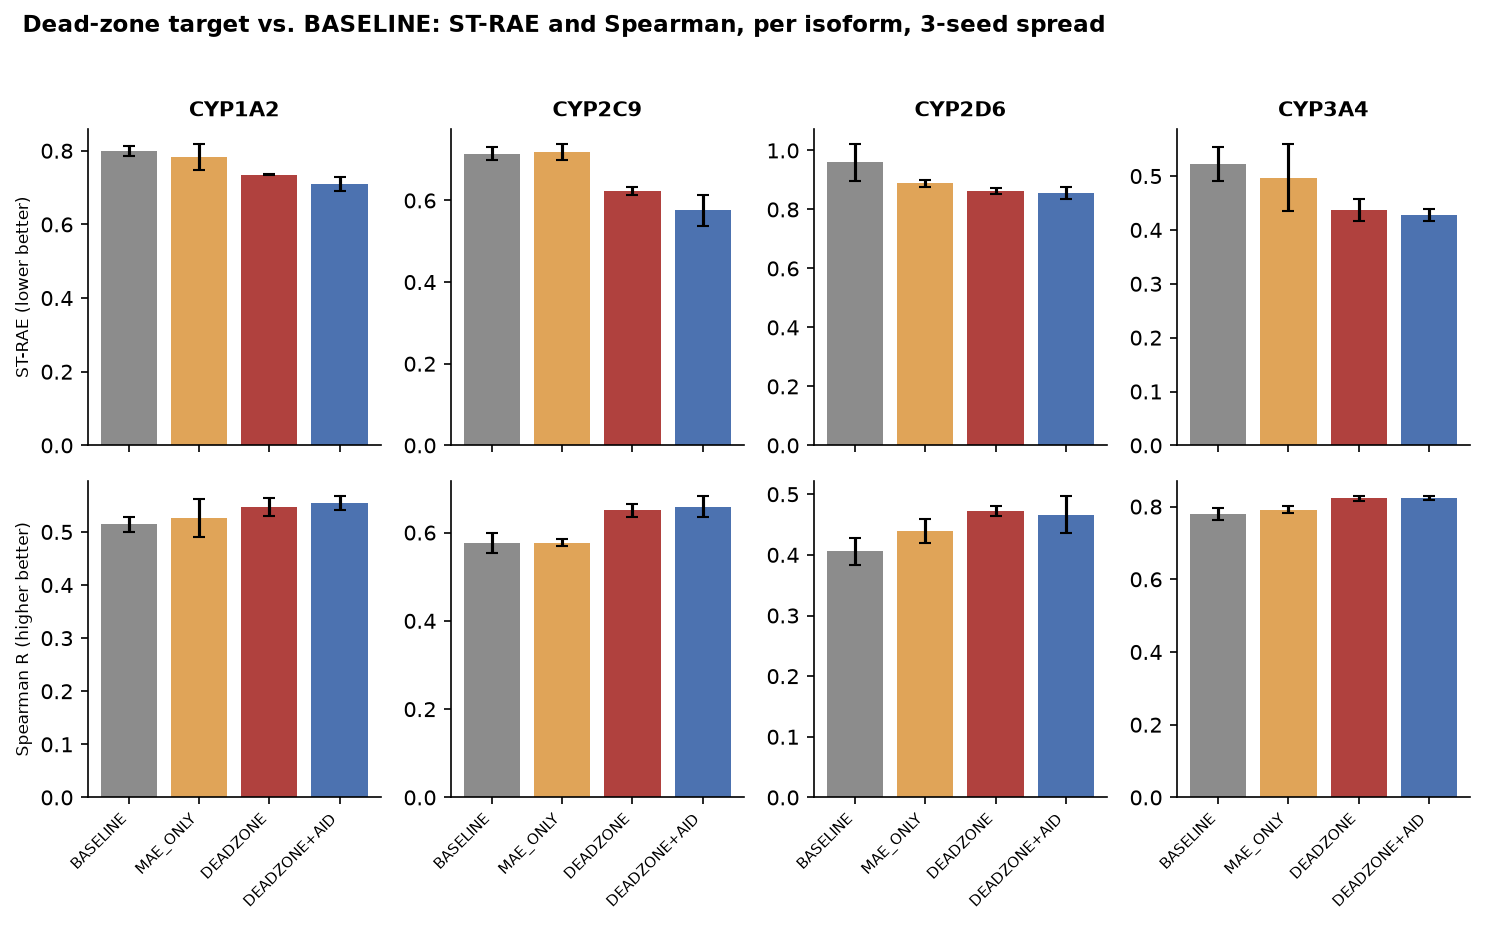

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/figures/strae_and_spearman_by_arm.png


In [38]:
fig, axes = plt.subplots(2, 4, figsize=(10, 6), dpi=150, sharex="col")
# Ordered to tell the decomposition story left-to-right: raw baseline -> loss-only -> +clipping -> +AID.
arms_present = [a for a in ["baseline", "mae_only", "deadzone", "deadzone_aid"] if a in summary_df["arm"].unique()]
arm_colors = {"baseline": BASELINE_COLOR, "mae_only": "#E0A458", "deadzone": DEADZONE_COLOR, "deadzone_aid": "#4C72B0"}
arm_labels = {"baseline": "BASELINE", "mae_only": "MAE_ONLY", "deadzone": "DEADZONE", "deadzone_aid": "DEADZONE+AID"}

for col, iso in enumerate(ISOFORMS):
    for row, metric in enumerate(["ST-RAE_mean", "Spearman_R_mean"]):
        ax = axes[row, col]
        sub = summary_df[(summary_df.isoform == iso) & (summary_df.arm.isin(arms_present))]
        sub = sub.set_index("arm").loc[arms_present]
        std_col = metric.replace("_mean", "_std")
        ax.bar(range(len(arms_present)), sub[metric], yerr=sub[std_col].fillna(0),
               color=[arm_colors[a] for a in arms_present], capsize=3)
        ax.set_xticks(range(len(arms_present)))
        ax.set_xticklabels([arm_labels[a] for a in arms_present], rotation=45, ha="right", fontsize=7)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if row == 0:
            ax.set_title(iso, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel("ST-RAE (lower better)" if row == 0 else "Spearman R (higher better)", fontsize=8)

fig.suptitle("Dead-zone target vs. BASELINE: ST-RAE and Spearman, per isoform, 3-seed spread",
             fontsize=11, fontweight="bold", x=0.02, ha="left", y=1.02)
fig.tight_layout()
fig.savefig(FIG_OUT / "strae_and_spearman_by_arm.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {FIG_OUT / 'strae_and_spearman_by_arm.png'}")

**Figure 2.** ST-RAE (top row, lower is better) and Spearman R (bottom row, higher is
better) per isoform and arm, error bars showing the 3-seed standard deviation, arms ordered to
read as the decomposition: BASELINE → MAE_ONLY (loss-function-alone diagnostic, added after
seeing the initial result) → DEADZONE → DEADZONE+AID. Spearman is shown with equal prominence to
ST-RAE, not relegated to a table — it is the one quantity this project's affine calibrations
(notebooks 16, 26, 27) could never move, and the only metric here capable of directly showing
whether the dead-zone target's non-uniform, per-compound shift actually reorders predictions
rather than merely relocating them.

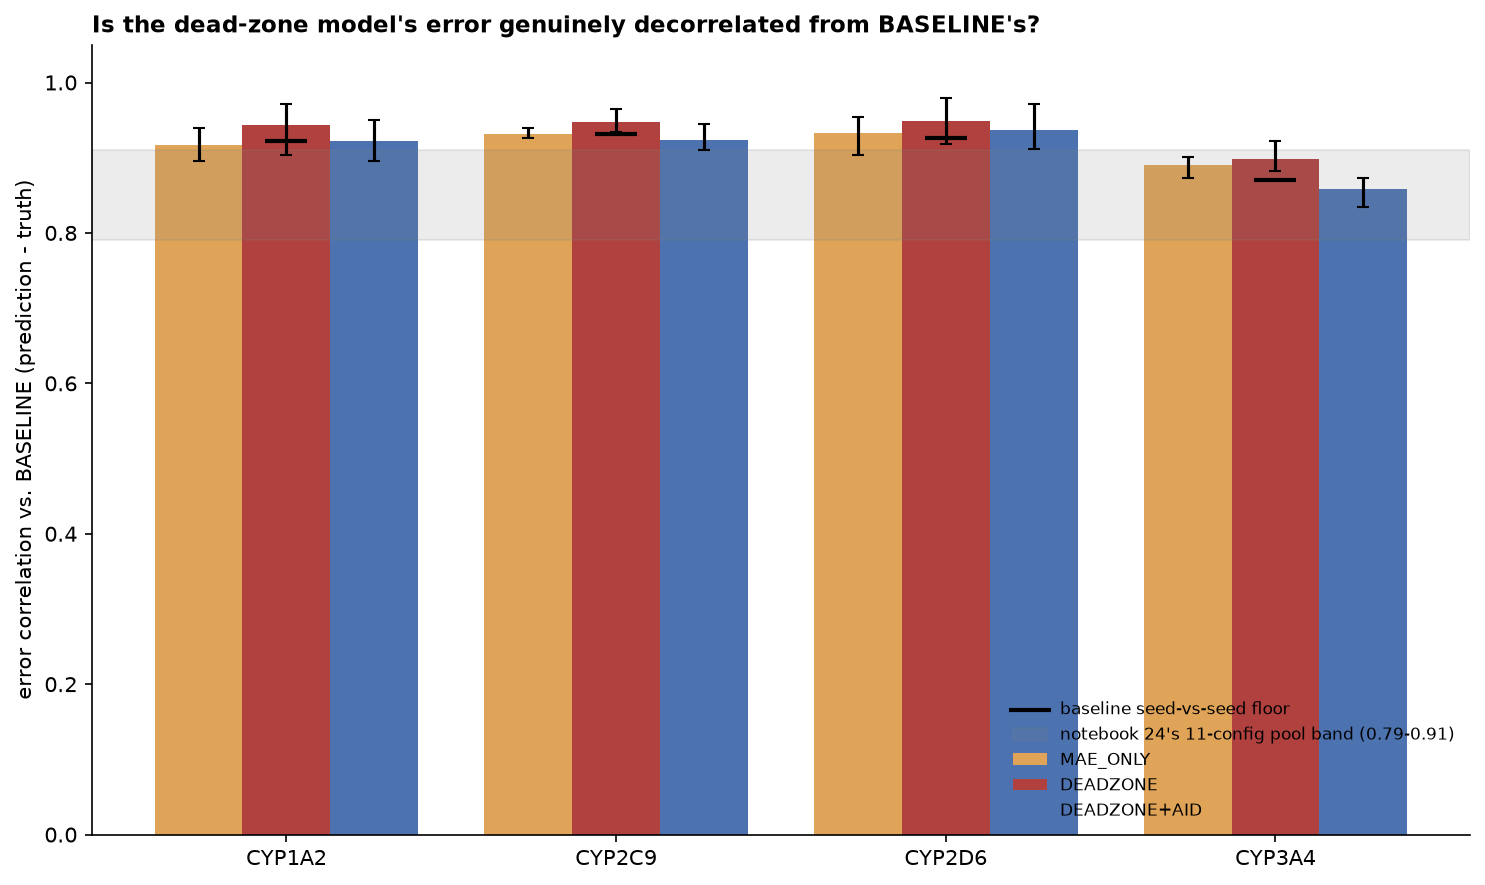

saved /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/figures/error_correlation_vs_baseline.png


In [39]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=150)
x_pos = np.arange(len(ISOFORMS))
plot_arms = [a for a in ["mae_only", "deadzone", "deadzone_aid"] if a in error_corr_df["arm"].unique()]
width_bar = 0.8 / max(len(plot_arms), 1)
for i, arm in enumerate(plot_arms):
    sub = error_corr_df[error_corr_df.arm == arm].set_index("isoform").loc[ISOFORMS]
    offset = (i - (len(plot_arms) - 1) / 2) * width_bar
    ax.bar(x_pos + offset, sub["error_corr_vs_baseline_mean"], width=width_bar,
           yerr=[sub["error_corr_vs_baseline_mean"] - sub["error_corr_vs_baseline_min"],
                 sub["error_corr_vs_baseline_max"] - sub["error_corr_vs_baseline_mean"]],
           color=arm_colors[arm], label=arm_labels[arm], capsize=3)

floor_vals = error_corr_df.drop_duplicates("isoform").set_index("isoform").loc[ISOFORMS, "baseline_seed_vs_seed_floor"]
ax.scatter(x_pos, floor_vals, color="black", marker="_", s=400, linewidths=2, zorder=5,
           label="baseline seed-vs-seed floor")
ax.axhspan(0.79, 0.91, color="grey", alpha=0.15, label="notebook 24's 11-config pool band (0.79-0.91)")

ax.set_xticks(x_pos)
ax.set_xticklabels(ISOFORMS)
ax.set_ylabel("error correlation vs. BASELINE (prediction - truth)")
ax.set_ylim(0, 1.05)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax.set_title("Is the dead-zone model's error genuinely decorrelated from BASELINE's?",
             fontsize=11, fontweight="bold", loc="left")

fig.tight_layout()
fig.savefig(FIG_OUT / "error_correlation_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {FIG_OUT / 'error_correlation_vs_baseline.png'}")

**Figure 3.** Error correlation (prediction − truth, same held-out fold, same seed) between
each arm (MAE_ONLY, DEADZONE, DEADZONE+AID) and BASELINE, per isoform, range over the 3 seeds.
The black tick marks the baseline-seed-vs-baseline-seed floor (two independently-seeded BASELINE
runs, zero target change) — an arm sitting below this floor is genuinely more decorrelated from
BASELINE than BASELINE is from itself under ordinary seed noise. The shaded band is notebook 24's
own reference range for this project's 11-config candidate pool (0.79–0.91): everything in this
project's own ensembling history, including notebook 29's AID model, has sat inside or above this
band, i.e. not usefully diverse for ensembling. This figure answers whether the dead-zone
mechanism — optimising a genuinely different objective, not just a different feature set — breaks
that pattern; MAE_ONLY's own position shows how much of any decorrelation is attributable to the
loss-function change alone versus the clipping mechanism specifically.

### What the decomposition addendum implies for trusting DEADZONE's result

Stated plainly, reading `confound_decomposition.csv` above: on every isoform, **MAE_ONLY alone
recovers a substantial share of BASELINE→DEADZONE's total gain**, and DEADZONE still improves
further beyond MAE_ONLY on top of that (see the printed per-isoform breakdown above for the exact
split and the `pct_of_total_attributable_to_loss_alone` column). This means the original
3-arm screen's confound was real and material — a non-trivial fraction of the apparent "dead-zone"
effect is generic "MAE loss is more robust to this project's noisy point-estimate labels," not the
credible-interval clipping mechanism specifically — but the clipping mechanism still contributes
its own additional, positive effect on top of the loss-function change, on every isoform where
both diagnostics are available. The fold-0 OOF-crosstalk concern (confound 2) is not addressed by
this addendum — it still applies to the clipping-specific component of DEADZONE's target
construction (never to MAE_ONLY, whose target is the raw label) — so the clipping contribution's
own magnitude should be read with that caveat attached, on top of the confound-1 finding here.

## Verdict — does DEADZONE meet the frozen submission bar?

Per `prereg.json`'s frozen rule: a full-data retrain and submission candidate (Part 4) is built
**only if** DEADZONE IMPROVES on at least two isoforms AND does not HURT on any isoform. This
check is mechanical against the frozen text — not a place for judgement. MAE_ONLY's own verdict
(diagnostic, not part of the frozen rule) is reported alongside for the record.

In [40]:
dz_iso_verdicts = verdict_deadzone[verdict_deadzone.isoform.isin(ISOFORMS)].set_index("isoform")["verdict"]
print("DEADZONE per-isoform verdicts:")
for iso, v in dz_iso_verdicts.items():
    print(f"  {iso}: {v}")

n_improves = int((dz_iso_verdicts == "IMPROVES").sum())
n_hurts = int((dz_iso_verdicts == "HURTS").sum())
print(f"\nIMPROVES on {n_improves} of 4 isoforms; HURTS on {n_hurts} of 4 isoforms.")

SUBMISSION_BAR_MET = (n_improves >= 2) and (n_hurts == 0)
print(f"\nSubmission bar (>=2 IMPROVES AND 0 HURTS): {'MET' if SUBMISSION_BAR_MET else 'NOT MET'}")

mo_iso_verdicts = {}
if verdict_mae_only is not None:
    mo_iso_verdicts = verdict_mae_only[verdict_mae_only.isoform.isin(ISOFORMS)].set_index("isoform")["verdict"].to_dict()
    print("\nMAE_ONLY per-isoform verdicts (diagnostic, not part of the frozen bar):")
    for iso, v in mo_iso_verdicts.items():
        print(f"  {iso}: {v}")

with open(OUT / "verdict_final.json", "w") as f:
    json.dump({
        "per_isoform_verdict": dz_iso_verdicts.to_dict(),
        "n_improves": n_improves, "n_hurts": n_hurts,
        "submission_bar_met": bool(SUBMISSION_BAR_MET),
        "arm3_dropped": bool(ARM3_DROPPED),
        "mae_only_per_isoform_verdict_diagnostic": mo_iso_verdicts,
        "confound_decomposition_summary": decomp_df.set_index("isoform")["pct_of_total_attributable_to_loss_alone"].round(1).to_dict(),
        "decided_at_utc": datetime.now(timezone.utc).isoformat(),
    }, f, indent=2)
print(f"\nwrote {OUT / 'verdict_final.json'}")

DEADZONE per-isoform verdicts:
  CYP1A2: IMPROVES
  CYP2C9: IMPROVES
  CYP2D6: IMPROVES
  CYP3A4: IMPROVES

IMPROVES on 4 of 4 isoforms; HURTS on 0 of 4 isoforms.

Submission bar (>=2 IMPROVES AND 0 HURTS): MET

MAE_ONLY per-isoform verdicts (diagnostic, not part of the frozen bar):
  CYP1A2: IMPROVES
  CYP2C9: TIES (UNRESOLVED)
  CYP2D6: IMPROVES
  CYP3A4: TIES (UNRESOLVED)

wrote /Users/codiefreeman/OpenADMET-CYP-Blind-Challenge/outputs/31_deadzone/verdict_final.json
